<a href="https://colab.research.google.com/github/15003165-code/Proyecto/blob/main/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - Text Mining & Image Recognition
### Postgrado en Análisis y Predicción de Datos - Tercer Trimestre 2026

Este notebook contiene la solución completa de los dos ejercicios del proyecto final:

- **Problema 1:** Word Cloud sobre un dataset de tweets (menciones más citadas y su contexto).
- **Problema 2:** Fruits and Vegetables Recognizer con redes neuronales convolucionales (CNN).


# Problema 1 - Word Cloud
### Text Mining & Image Recognition - Proyecto Final

En este notebook vamos a trabajar con un dataset de aproximadamente 1.6 millones de tweets.

**Pasos que vamos a seguir:**
1. Cargar el dataset.
2. Usar expresiones regulares (regex) para encontrar las menciones `@usuario` dentro de los tweets.
3. Determinar los 3 usuarios más citados (más mencionados) en todo el dataset.
4. Armar un corpus por cada uno de esos 3 usuarios (Content, ID, Timestamp, Length).
5. Limpiar el texto, quitar stopwords, y aplicar stemming + lematización.
6. Analizar el contexto (palabras cercanas a la mención) para entender **por qué** se cita a cada usuario.
7. Mostrar un WordCloud con las 10 palabras de contexto más frecuentes por usuario.


In [ ]:
# Instala las librerias necesarias en el Python que esta ejecutando este notebook.
# (Si ya estan instaladas, no hace nada; en Google Colab tambien funciona.)
%pip install wordcloud nltk --quiet


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd                  # para manejar el dataset como tabla
import re                            # para expresiones regulares (regex)
import html                          # para "traducir" códigos HTML como &quot; a su símbolo real
from collections import Counter      # para contar palabras/menciones fácilmente

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:
# Descargamos los recursos que necesita nltk (solo hace falta la primera vez)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\brady\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\brady\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\brady\AppData\Roaming\nltk_data...


[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Paso 1: Cargar el dataset

El archivo `tw_source.csv` no trae fila de encabezado, así que le ponemos nombres a las columnas
nosotros mismos: `target`, `id`, `timestamp`, `query`, `author`, `text`.

Usamos `encoding="latin-1"` porque el archivo no está guardado en UTF-8 (si se usa UTF-8 da error).


### Cómo correr este notebook en Google Colab

Este notebook necesita dos datasets que **no vienen incluidos** en Colab:
el archivo `tw_source.csv` (Problema 1) y la carpeta `Fruits_Vegetables_Dataset(12000)`
(Problema 2; si la tienes comprimida como `Fruits_Vegetables_Dataset(12000).zip`, también sirve).

**Guárdalos en tu Google Drive, directamente en "Mi unidad"** (no hace falta ninguna carpeta).
Al ejecutar la siguiente celda, Colab pedirá permiso para conectar tu Drive: acéptalo.
El notebook siempre los busca ahí.

Si corres el notebook en tu computadora, deben estar en la misma carpeta que el notebook.

**En Colab, además:**
- Los modelos entrenados, historiales, figuras y el manifiesto del Problema 2 se guardan en la carpeta
  `_artefactos_proyecto` de tu Drive (Mi unidad), para no perderlos si Colab reinicia el entorno.
  Si vuelves a ejecutar el notebook, los modelos guardados se cargan sin reentrenar.
- El caché de imágenes redimensionadas (unos 345 MB) se guarda en el disco temporal de Colab, porque
  leerlo desde Drive sería lento; si el entorno se reinicia se regenera solo.
- Se recomienda activar GPU: *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU*.


In [ ]:
import os
import sys

# Detectamos si estamos en Google Colab
EN_COLAB = "google.colab" in sys.modules

DRIVE = "/content/drive/MyDrive"

# En Colab, siempre conectamos tu Google Drive y buscamos ahi los archivos
if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")


def buscar(nombre):
    """Busca un archivo o carpeta por su nombre.
    En Colab: en 'Mi unidad' de Drive y, si no esta ahi, dentro de sus subcarpetas.
    En tu computadora: en la carpeta donde esta el notebook."""
    if not EN_COLAB:
        if os.path.exists(nombre):
            return nombre
    else:
        ruta = os.path.join(DRIVE, nombre)
        if os.path.exists(ruta):
            return ruta
        for raiz, carpetas, archivos in os.walk(DRIVE):
            if nombre in archivos or nombre in carpetas:
                return os.path.join(raiz, nombre)

    raise FileNotFoundError(f"No encontre '{nombre}'. Guardalo en Mi unidad de Google Drive.")


In [ ]:
# Nombres de las columnas del dataset
columnas = ["target", "id", "timestamp", "query", "author", "text"]

# Leemos el csv
df = pd.read_csv(buscar("tw_source.csv"), header=None, names=columnas, encoding="latin-1")

print("Cantidad de tweets en el dataset:", len(df))
df.head()


Cantidad de tweets en el dataset: 1600000


,target,id,timestamp,query,author,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## Paso 2: Encontrar los usuarios más citados con expresiones regulares

Un tweet "cita" o menciona a un usuario cuando escribe `@nombre_usuario` dentro del texto
(por ejemplo: `@mileycyrus i love you!!`).

Usamos una expresión regular para extraer todas las menciones de cada tweet y así contar
cuántas veces se menciona a cada usuario en todo el dataset.


In [ ]:
# Esta expresión regular busca un @ seguido de letras/números/guion_bajo (\w+)
patron_mencion = re.compile(r"@(\w+)")

def extraer_menciones(texto):
    # findall regresa una lista con TODAS las menciones que encuentre en el texto
    return patron_mencion.findall(texto.lower())

# Aplicamos la función a cada tweet y vamos sumando todas las menciones encontradas
contador_menciones = Counter()
for lista_menciones in df["text"].apply(extraer_menciones):
    contador_menciones.update(lista_menciones)

# Tomamos los 3 usuarios con más menciones (los "más populares")
top_3 = contador_menciones.most_common(3)

print("Los 3 usuarios más citados son:")
for usuario, cantidad in top_3:
    print(f"  @{usuario}: {cantidad} menciones")

# Guardamos solo los nombres de usuario en una lista para usarlos más adelante
usuarios_top = [usuario for usuario, cantidad in top_3]
usuarios_top


Los 3 usuarios más citados son:
  @mileycyrus: 4580 menciones
  @tommcfly: 3904 menciones
  @ddlovato: 3474 menciones


['mileycyrus', 'tommcfly', 'ddlovato']

## Paso 3: Armar el corpus de cada usuario

Por cada uno de los 3 usuarios más citados, construimos un corpus (una tabla) con:
- **Content**: el texto del tweet.
- **ID**: identificador del tweet.
- **Timestamp**: fecha y hora del tweet.
- **Length**: cantidad de caracteres del tweet (este valor lo calculamos nosotros).

Cada corpus solo contiene los tweets que **mencionan** a ese usuario.


In [ ]:
def tweet_menciona_usuario(texto, usuario):
    # \b significa "límite de palabra": evita que @tom haga match dentro de @tommcfly
    return re.search(rf"@{usuario}\b", texto, flags=re.IGNORECASE) is not None

corpus_por_usuario = {}

for usuario in usuarios_top:
    # Filtramos solo los tweets que mencionan a este usuario
    filtro = df["text"].apply(lambda texto: tweet_menciona_usuario(texto, usuario))
    subconjunto = df[filtro].copy()

    # Length = cantidad de caracteres del tweet
    subconjunto["Length"] = subconjunto["text"].str.len()

    # Nos quedamos solo con las columnas que pide el corpus, con los nombres pedidos
    corpus = subconjunto[["text", "id", "timestamp", "Length"]].rename(
        columns={"text": "Content", "id": "ID", "timestamp": "Timestamp"}
    ).reset_index(drop=True)

    corpus_por_usuario[usuario] = corpus
    print(f"Corpus de @{usuario}: {len(corpus)} tweets")


Corpus de @mileycyrus: 4562 tweets


Corpus de @tommcfly: 3898 tweets


Corpus de @ddlovato: 3460 tweets


In [ ]:
# Vista rápida del corpus del primer usuario del top 3
corpus_por_usuario[usuarios_top[0]].head()


,Content,ID,Timestamp,Length
0,@mileycyrus hahaha dont be like that one time ...,1468063101,Mon Apr 06 23:30:57 PDT 2009,107
1,"@mileycyrus i have the same problem, but it's ...",1468286517,Tue Apr 07 00:45:20 PDT 2009,137
2,@mileycyrus I guess counting sheep didn't work...,1468297110,Tue Apr 07 00:49:07 PDT 2009,72
3,@mileycyrus I would too if it meant spending a...,1468298918,Tue Apr 07 00:49:44 PDT 2009,100
4,@mileycyrus AWWW u seriously have the cutest d...,1468318249,Tue Apr 07 00:56:41 PDT 2009,112


## Paso 4: Limpiar el texto y extraer el contexto de cada mención

Para entender **por qué** se cita a un usuario, revisamos qué palabras aparecen cerca de la
mención: las 5 palabras antes y las 5 palabras después.

Antes de contar las palabras, limpiamos el texto siguiendo estos pasos:

1. Convertir códigos HTML como `&quot;` a su símbolo real (`"`). Esto es necesario porque el
   dataset trae estos códigos sin traducir y si no los limpiamos aparecen como palabras falsas
   (por ejemplo "quot").
2. Pasar todo a minúsculas.
3. Quitar links (http...).
4. Quitar números y signos de puntuación.
5. Quitar "stopwords" (palabras muy comunes sin significado propio: the, and, is, etc.).
6. Aplicar **lematización** (llevar la palabra a su forma base, ej. "loving" -> "love").
7. Aplicar **stemming** (recortar la palabra a su raíz, ej. "loving" -> "lov").


In [ ]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lematizador = WordNetLemmatizer()

def limpiar_texto(texto):
    texto = html.unescape(texto)                     # &quot; -> "
    texto = texto.lower()                             # todo a minúsculas
    texto = re.sub(r"http\S+|www\S+", "", texto)     # quitar links
    texto = re.sub(r"[^a-z@\s]", " ", texto)          # dejar solo letras, @ y espacios
    return texto

def obtener_contexto(texto, usuario, ventana=5):
    texto_limpio = limpiar_texto(texto)
    palabras = texto_limpio.split()
    mencion = f"@{usuario}"

    # Si por algún motivo la mención ya no aparece después de limpiar, no hay contexto
    if mencion not in palabras:
        return []

    posicion = palabras.index(mencion)
    inicio = max(0, posicion - ventana)
    fin = posicion + ventana + 1

    # Palabras antes y después de la mención (sin incluir la mención misma)
    contexto = palabras[inicio:posicion] + palabras[posicion + 1:fin]

    # Quitamos stopwords, palabras muy cortas (1-2 letras) y otras menciones
    contexto = [p for p in contexto if p not in stop_words and len(p) > 2 and not p.startswith("@")]

    # Primero lematizamos y después aplicamos stemming
    contexto = [lematizador.lemmatize(p) for p in contexto]
    contexto = [stemmer.stem(p) for p in contexto]

    return contexto


## Paso 5: Top 10 palabras de contexto por usuario

Ahora recorremos todos los tweets del corpus de cada usuario, juntamos las palabras de
contexto de todos ellos, y contamos cuáles son las 10 más frecuentes.


In [ ]:
top_palabras_por_usuario = {}

for usuario in usuarios_top:
    todas_las_palabras = []
    for texto in corpus_por_usuario[usuario]["Content"]:
        todas_las_palabras.extend(obtener_contexto(texto, usuario))

    contador = Counter(todas_las_palabras)
    top_10 = dict(contador.most_common(10))
    top_palabras_por_usuario[usuario] = top_10

    print(f"Top 10 palabras de contexto para @{usuario}:")
    for palabra, cantidad in top_10.items():
        print(f"  {palabra}: {cantidad}")
    print()


Top 10 palabras de contexto para @mileycyrus:
  miley: 588
  love: 363
  vote: 267
  hey: 175
  good: 172
  come: 164
  hope: 157
  pleas: 112
  luck: 104
  best: 98



Top 10 palabras de contexto para @tommcfly:
  tom: 562
  say: 174
  hey: 154
  pleas: 148
  love: 144
  good: 137
  come: 117
  like: 103
  haha: 97
  miss: 95



Top 10 palabras de contexto para @ddlovato:
  demi: 420
  love: 252
  wish: 164
  hey: 119
  come: 115
  hope: 105
  pleas: 103
  wait: 92
  awesom: 90
  could: 87



## Paso 6: WordCloud por usuario

Por último, mostramos un WordCloud (nube de palabras) por cada usuario, usando las
10 palabras de contexto más frecuentes que calculamos en el paso anterior.


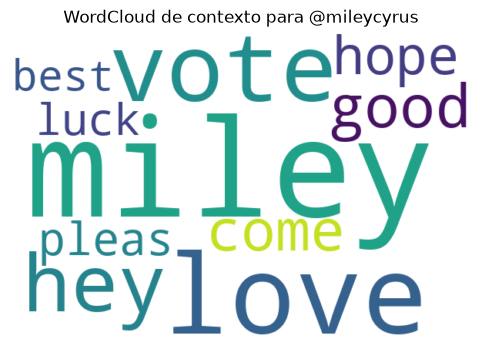

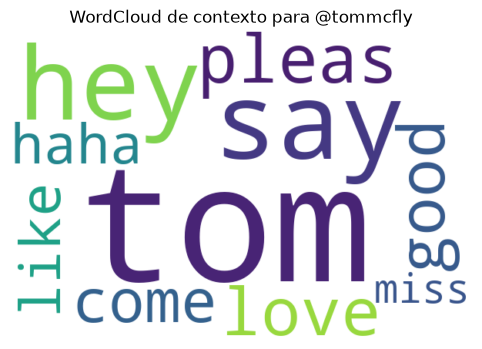

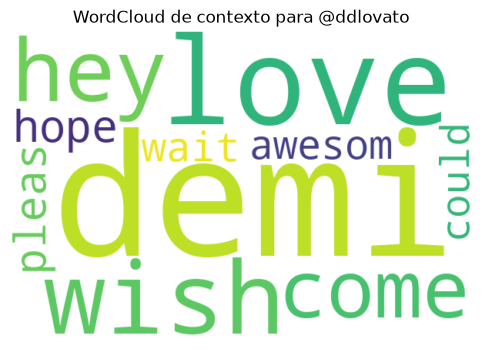

In [ ]:
for usuario in usuarios_top:
    frecuencias = top_palabras_por_usuario[usuario]

    wc = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(frecuencias)

    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud de contexto para @{usuario}")
    plt.show()


## Conclusión: ¿por qué se cita a cada usuario?

Con base en las palabras de contexto obtenidas para el top 3 (`@mileycyrus`, `@tommcfly`,
`@ddlovato`), podemos observar lo siguiente:

- **@mileycyrus**: palabras como *miley, love, vote, hope, luck, best* muestran que la mayoría
  de las menciones son de fans expresando cariño, pidiendo votos (posiblemente para algún
  premio o concurso) y deseándole suerte.
- **@tommcfly**: palabras como *tom, say, please, love, miss* sugieren mensajes de fans
  pidiéndole atención/respuesta y expresando que lo extrañan.
- **@ddlovato**: palabras como *demi, love, wish, hope, please, awesome* indican mensajes de
  fans expresando admiración y esperando alguna respuesta de ella.

En los tres casos el patrón es similar: son **celebridades (cantantes/actrices)** mencionadas
principalmente por sus **fans**, con mensajes de cariño, apoyo y peticiones de respuesta,
algo típico de Twitter en el año en que se recolectó este dataset (2009).


---
---
# Problema 2: Fruits and Vegetables Recognizer
---
---


# 01. Introducción

El reconocimiento automático de frutas y vegetales tiene aplicaciones directas en clasificación en líneas de empaque, control de calidad, inventario en retail y accesibilidad. Este proyecto desarrolla un clasificador de imágenes basado en **Redes Neuronales Convolucionales (CNN)** capaz de distinguir **seis clases**: tres frutas (*Apple, Banana, Mango*) y tres vegetales (*Bellpepper, Carrot, Cucumber*).

**Particularidad del dataset.** Cada producto viene separado en dos carpetas según su estado (*Fresh* y *Rotten*), es decir, 12 carpetas. La consigna pide reconocer el **tipo de producto**, no su estado; por ello *Fresh/Rotten* **no** se convierten en clases: se tratan como **variabilidad interna** de cada clase (un mismo producto luce muy distinto fresco y podrido) y se conservan como **metadato** para un análisis complementario (sección 23).

**Enfoque metodológico.**
1. Auditar los datos reales (conteos, formatos, corruptos, tamaños, duplicados) antes de diseñar nada.
2. Construir un pipeline eficiente en memoria, sin duplicar imágenes en disco y sin *data leakage*.
3. Entrenar y comparar **tres arquitecturas CNN** distintas bajo exactamente las mismas condiciones.
4. Seleccionar el mejor modelo con criterios múltiples (no solo accuracy) y **sin usar Test para decidir hiperparámetros**.
5. Analizar errores, el efecto Fresh/Rotten y limitaciones.

> Todas las cifras de este notebook se calculan al ejecutarlo sobre el dataset local. Los textos interpretativos que citan números se generan a partir de esos resultados.

# 02. Objetivos

**Objetivo general.** Desarrollar y comparar modelos CNN para clasificar imágenes de seis tipos de frutas y vegetales, y determinar cuál arquitectura generaliza mejor.

**Objetivos específicos.**
1. Auditar el dataset local y verificar que las 12 carpetas corresponden a las 6 clases indicadas.
2. Aplicar redimensionamiento (128×128), normalización (0–1) y *Data Augmentation* solo sobre Train.
3. Dividir los datos de forma reproducible en 70 % / 15 % / 15 % con `SEED = 42`, evitando *leakage* (incluidos duplicados exactos).
4. Diseñar y entrenar tres CNN: **baseline**, **profunda con BatchNormalization** y **regularizada con GlobalAveragePooling**.
5. Evaluar con Accuracy, Precision, Recall, F1 y matrices de confusión; seleccionar el mejor modelo con criterios justificados.
6. Responder la pregunta central: **¿por qué la CNN seleccionada funciona mejor que las otras?**

# 03. Configuración

**Qué se hará:** importar librerías, definir **una única variable de ruta** (`DATASET_DIR`), fijar hiperparámetros globales y semillas, detectar GPU y definir funciones auxiliares reutilizables.

**Por qué:** centralizar la configuración evita rutas duplicadas y garantiza reproducibilidad (`SEED = 42`).

**Qué esperamos:** que el notebook funcione en CPU (con o sin GPU) y que todas las rutas se deriven de `DATASET_DIR`.

> `DATASET_DIR` apunta a la carpeta original `Fruits_Vegetables_Dataset(12000)` (con `Fruits/` y `Vegetables/`). Se localiza con la misma función `buscar()` del Problema 1 y, si solo existe el `.zip`, se descomprime. Los artefactos (caché, modelos, figuras) se guardan en `_artefactos_proyecto/` junto al notebook, no dentro del dataset.

In [ ]:
import os, re, json, hashlib, time, warnings, random, zipfile
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from PIL import Image, ImageOps
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier

try:
    from tqdm import tqdm
except Exception:                       # tqdm es opcional
    def tqdm(x, **kw): return x

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25})

# ─────────────────────────────  RUTA ÚNICA  ─────────────────────────────
_DATASET = "Fruits_Vegetables_Dataset(12000)"
if not os.path.isdir(_DATASET):
    try:
        _DATASET = buscar(_DATASET)                  # Colab: Mi unidad de Drive (buscar() viene del Problema 1)
    except FileNotFoundError:
        print("Descomprimiendo el dataset de frutas, esto puede tardar un par de minutos...")
        with zipfile.ZipFile(buscar(_DATASET + ".zip"), "r") as zip_ref:
            zip_ref.extractall(".")
DATASET_DIR = _DATASET      # <- ÚNICA variable de ruta al dataset. Todo lo demás se deriva de ella.
# ─────────────────────────────────────────────────────────────────────────

# Hiperparámetros y banderas globales
SEED = 42
IMG_SIZE = (128, 128)
N_CHANNELS = 3                                   # RGB (se justifica en la sección 09)
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
BATCH_SIZE = 32
EPOCHS = 30                                      # máximo; EarlyStopping suele detener antes
LEARNING_RATE = 1e-3
N_WORKERS = min(8, (os.cpu_count() or 4))

REBUILD_MANIFEST = False    # True: vuelve a auditar todos los archivos (lento en OneDrive)
REBUILD_CACHE = False       # True: vuelve a generar el caché redimensionado
FORCE_RETRAIN = False       # True: reentrena aunque existan modelos guardados
CHECK_DUPLICATES = True     # hash MD5 para detectar duplicados exactos

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}

CLASS_MAPPING = {
    "FreshApple": "Apple",           "RottenApple": "Apple",
    "FreshBanana": "Banana",         "RottenBanana": "Banana",
    "FreshMango": "Mango",           "RottenMango": "Mango",
    "FreshBellpepper": "Bellpepper", "RottenBellpepper": "Bellpepper",
    "FreshCarrot": "Carrot",         "RottenCarrot": "Carrot",
    "FreshCucumber": "Cucumber",     "RottenCucumber": "Cucumber",
}
CLASSES = sorted(set(CLASS_MAPPING.values()))            # orden alfabético = id de clase
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
N_CLASSES = len(CLASSES)
GRUPO = {"Apple": "Fruta", "Banana": "Fruta", "Mango": "Fruta",
         "Bellpepper": "Vegetal", "Carrot": "Vegetal", "Cucumber": "Vegetal"}

# Todas las rutas se derivan de DATASET_DIR
ROOT = Path(DATASET_DIR).resolve()
assert ROOT.is_dir(), f"DATASET_DIR no existe o no es una carpeta: {ROOT}"
if EN_COLAB:
    ARTIFACTS_DIR = Path(DRIVE) / "_artefactos_proyecto"        # en Drive: sobrevive a reinicios de Colab
    CACHE_DIR = Path("_cache_proyecto").resolve()               # caché en disco local de Colab (Drive sería lento)
else:
    ARTIFACTS_DIR = Path("_artefactos_proyecto").resolve()      # junto al notebook, fuera del dataset
    CACHE_DIR = ARTIFACTS_DIR / "cache"
for sub in ["modelos", "historiales", "figuras"]:
    (ARTIFACTS_DIR / sub).mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def set_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
set_seeds()

# Detección de hardware
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
print("GPU detectada:", [g.name for g in gpus] if gpus else "ninguna → se entrenará en CPU (funciona igual, más lento)")
print("Núcleos de CPU:", os.cpu_count())
print("Carpeta raíz:", ROOT)

# ───────────────────────── funciones auxiliares ─────────────────────────
def md(texto):
    display(Markdown(texto))

def savefig(nombre):
    plt.savefig(ARTIFACTS_DIR / "figuras" / f"{nombre}.png", bbox_inches="tight", dpi=130)

def norm(s):
    return re.sub(r"[^a-z0-9]", "", s.lower())

def load_rgb(path, size=IMG_SIZE):
    """Carga una imagen como array uint8 RGB. Maneja RGBA/P (fondo blanco), CMYK, WebP y orientación EXIF."""
    with Image.open(path) as im:
        try:
            im.draft("RGB", (size[1] * 2, size[0] * 2))     # acelera JPEG gigantes
        except Exception:
            pass
        im = ImageOps.exif_transpose(im)
        if im.mode in ("RGBA", "LA") or (im.mode == "P" and "transparency" in im.info):
            im = im.convert("RGBA")
            fondo = Image.new("RGB", im.size, (255, 255, 255))
            fondo.paste(im, mask=im.split()[-1])
            im = fondo
        else:
            im = im.convert("RGB")
        if size is not None:
            im = im.resize((size[1], size[0]), Image.BILINEAR)
        return np.asarray(im, dtype=np.uint8)

def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n
    den = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    mar = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return (centro - mar, centro + mar)

if tuple(int(x) for x in tf.__version__.split(".")[:2]) < (2, 12):
    print("AVISO: se recomienda TensorFlow >= 2.12 (formato de modelo .keras).")

TensorFlow: 2.21.0 | Keras: 3.15.1
GPU detectada: ninguna → se entrenará en CPU (funciona igual, más lento)
Núcleos de CPU: 4
Carpeta raíz: C:\Users\brady\OneDrive - Universidad Galileo\Documentos\TEXT MINING & IMAGE RECOGNITION\proyecto final\Fruits_Vegetables_Dataset(12000)


# 04. Auditoría del dataset

**Qué se hará:** localizar las 12 carpetas dentro de `DATASET_DIR`, verificar que coinciden con el `CLASS_MAPPING` y auditar cada imagen: extensión, si abre correctamente, dimensiones, canales y hash MD5 (duplicados exactos).

**Por qué:** no se debe diseñar ninguna CNN sin conocer los datos reales. Además, decisiones posteriores (lector de imágenes, tamaño de entrada, tratamiento de duplicados) dependen de esta auditoría.

**Qué esperamos:** 12 carpetas encontradas, cero archivos corruptos y heterogeneidad en tamaños, formatos y canales.

La auditoría es de **solo lectura**: no se copia ni se modifica ninguna imagen. El resultado (manifiesto) se guarda en `_artefactos_proyecto/` para no repetir el hash en cada ejecución.

In [ ]:
def descubrir_carpetas(root, mapping):
    esperado = {norm(k): k for k in mapping}
    encontradas = {k: [] for k in mapping}
    otras = []
    for d in [root] + [p for p in root.rglob("*") if p.is_dir()]:
        if d == ARTIFACTS_DIR or ARTIFACTS_DIR in d.parents:
            continue
        n_img = sum(1 for f in d.iterdir() if f.is_file() and f.suffix.lower() in IMG_EXT)
        if norm(d.name) in esperado:
            encontradas[esperado[norm(d.name)]].append(d)
        elif n_img > 0:
            otras.append((d, n_img))
    return encontradas, otras

found, otras_con_imagenes = descubrir_carpetas(ROOT, CLASS_MAPPING)
print("── Carpetas esperadas ──")
for k, paths in found.items():
    estado = "OK" if len(paths) == 1 else ("FALTA" if not paths else "MÚLTIPLES")
    print(f"{estado:9s} {k:16s} → {CLASS_MAPPING[k]:11s} {[str(p.relative_to(ROOT)) for p in paths]}")
print("\nCarpetas del dataset NO seleccionadas para este proyecto (se ignoran):",
      sorted(f"{p.name} ({n})" for p, n in otras_con_imagenes) if otras_con_imagenes else "ninguna")
faltan = [k for k, v in found.items() if not v]
assert not faltan, f"Faltan carpetas: {faltan}"
assert all(len(v) == 1 for v in found.values()), "Hay carpetas esperadas duplicadas en distintas ubicaciones"
print("\nRESULTADO: las 12 carpetas fueron encontradas exactamente una vez.")

# ── listado de archivos ──
archivos = [(k, f) for k, paths in found.items() for base in paths for f in base.rglob("*") if f.is_file()]
ext_todas = Counter(f.suffix.lower() for _, f in archivos)
imagenes = [(k, f) for k, f in archivos if f.suffix.lower() in IMG_EXT]
no_imagen = [f for k, f in archivos if f.suffix.lower() not in IMG_EXT]
print(f"Archivos totales: {len(archivos):,} | imágenes: {len(imagenes):,} | no-imagen: {len(no_imagen)}")

# ── auditoría por archivo (con caché en disco) ──
MANIFEST_CSV = ARTIFACTS_DIR / "manifest_auditoria.csv"

def auditar_archivo(par):
    key, f = par
    r = dict(carpeta=key, clase=CLASS_MAPPING[key],
             condicion="Fresh" if key.startswith("Fresh") else "Rotten",
             producto=key.replace("Fresh", "").replace("Rotten", ""),
             ruta=str(f), ext=f.suffix.lower(), ok=True, w=np.nan, h=np.nan,
             modo=None, md5=None, error=None)
    try:
        with Image.open(f) as im:
            im.verify()
        with Image.open(f) as im:
            r["w"], r["h"], r["modo"] = im.size[0], im.size[1], im.mode
    except Exception as e:
        r["ok"] = False; r["error"] = repr(e)
    if CHECK_DUPLICATES:
        r["md5"] = hashlib.md5(f.read_bytes()).hexdigest()
    return r

cache_ok = False
if MANIFEST_CSV.exists() and not REBUILD_MANIFEST:
    df = pd.read_csv(MANIFEST_CSV)
    cache_ok = (len(df) == len(imagenes)) and set(df["ruta"]) == {str(f) for _, f in imagenes}
    print("Manifiesto cargado desde caché." if cache_ok else "El caché no coincide con el disco: se regenera.")
if not cache_ok:
    with ThreadPoolExecutor(N_WORKERS) as ex:
        registros = list(tqdm(ex.map(auditar_archivo, imagenes), total=len(imagenes), desc="Auditando"))
    df = pd.DataFrame(registros)
    df.to_csv(MANIFEST_CSV, index=False)

df["ok"] = df["ok"].astype(bool)
df_ok = df[df["ok"]].copy()
print(f"\nImágenes registradas: {len(df):,} | legibles: {len(df_ok):,} | corruptas: {(~df['ok']).sum()}")
print("Extensiones (todos los archivos):", dict(ext_todas))

── Carpetas esperadas ──
OK        FreshApple       → Apple       ['Fruits\\FreshApple']
OK        RottenApple      → Apple       ['Fruits\\RottenApple']
OK        FreshBanana      → Banana      ['Fruits\\FreshBanana']
OK        RottenBanana     → Banana      ['Fruits\\RottenBanana']
OK        FreshMango       → Mango       ['Fruits\\FreshMango']
OK        RottenMango      → Mango       ['Fruits\\RottenMango']
OK        FreshBellpepper  → Bellpepper  ['Vegetables\\FreshBellpepper']
OK        RottenBellpepper → Bellpepper  ['Vegetables\\RottenBellpepper']
OK        FreshCarrot      → Carrot      ['Vegetables\\FreshCarrot']
OK        RottenCarrot     → Carrot      ['Vegetables\\RottenCarrot']
OK        FreshCucumber    → Cucumber    ['Vegetables\\FreshCucumber']
OK        RottenCucumber   → Cucumber    ['Vegetables\\RottenCucumber']

Carpetas del dataset NO seleccionadas para este proyecto (se ignoran): ['FreshOrange (609)', 'FreshPotato (615)', 'FreshStrawberry (603)', 'FreshTomato (604

Archivos totales: 7,201 | imágenes: 7,201 | no-imagen: 0


Auditando:   0%|          | 0/7201 [00:00<?, ?it/s]

Auditando:   0%|          | 27/7201 [00:00<00:27, 262.31it/s]

Auditando:   1%|          | 57/7201 [00:00<00:25, 280.72it/s]

...

Auditando:  99%|█████████▉| 7138/7201 [00:31<00:00, 243.47it/s]

Auditando:  99%|█████████▉| 7164/7201 [00:31<00:00, 244.51it/s]

Auditando: 100%|█████████▉| 7190/7201 [00:31<00:00, 211.76it/s]

Auditando: 100%|██████████| 7201/7201 [00:31<00:00, 226.01it/s]


Imágenes registradas: 7,201 | legibles: 7,201 | corruptas: 0
Extensiones (todos los archivos): {'.jpg': 6310, '.png': 841, '.jpeg': 39, '.webp': 11}


In [ ]:
# Tabla 1: Producto | Fresh | Rotten | Total
t1 = (df.pivot_table(index="producto", columns="condicion", values="ruta", aggfunc="count", fill_value=0)
        .reindex(columns=["Fresh", "Rotten"], fill_value=0))
t1["Total"] = t1.sum(axis=1)
t1.loc["TOTAL"] = t1.sum()
print("Tabla 1 – Producto | Fresh | Rotten | Total"); display(t1)

print("Extensiones de imagen:"); display(df["ext"].value_counts().to_frame("n"))
print("Modos de color / canales:"); display(df["modo"].value_counts(dropna=False).to_frame("n"))
print("Imágenes corruptas:", int((~df["ok"]).sum()))
if (~df["ok"]).any():
    display(df.loc[~df["ok"], ["carpeta", "ruta", "error"]])

print("Dimensiones (píxeles) de las imágenes legibles:")
display(df_ok[["w", "h"]].describe().round(1))
res_top = df_ok.groupby(["w", "h"]).size().sort_values(ascending=False)
print("Resoluciones más frecuentes:"); display(res_top.head(8).to_frame("n"))
df_ok["aspecto"] = df_ok["w"] / df_ok["h"]
print("Resolución y relación de aspecto por clase (mediana):")
display(df_ok.groupby("clase")[["w", "h", "aspecto"]].median().round(2))
print("Formato (extensión) por clase:")
display(pd.crosstab(df_ok["clase"], df_ok["ext"]))

n_dup_files = n_dup_groups = n_mixtos = n_cruzan = 0
if CHECK_DUPLICATES:
    dup = df_ok[df_ok.duplicated("md5", keep=False)]
    n_dup_files, n_dup_groups = len(dup), dup["md5"].nunique()
    n_cruzan = int((dup.groupby("md5")["clase"].nunique() > 1).sum())
    n_mixtos = int((dup.groupby("md5")["condicion"].nunique() > 1).sum())
    print(f"\nDuplicados exactos: {n_dup_files} archivos en {n_dup_groups} grupos | "
          f"grupos que cruzan clases: {n_cruzan} | grupos que mezclan Fresh y Rotten: {n_mixtos}")

n_no_rgb = int((df_ok["modo"] != "RGB").sum())
n_extra = n_dup_files - n_dup_groups
md(f"""**Resultado.** Se auditaron **{len(df):,}** imágenes: **{int(t1.loc['TOTAL','Fresh']):,} Fresh** y **{int(t1.loc['TOTAL','Rotten']):,} Rotten**, con **{int((~df['ok']).sum())}** archivos corruptos.

**Interpretación.**
- **Tamaños heterogéneos:** de {int(df_ok.w.min())}×{int(df_ok.h.min())} hasta {int(df_ok.w.max())}×{int(df_ok.h.max())} px; la resolución más frecuente es {res_top.index[0][0]}×{res_top.index[0][1]} ({int(res_top.iloc[0]):,} imágenes). Esto **justifica el redimensionamiento** a un tamaño estándar.
- **Formatos y canales:** {len(ext_todas)} extensiones distintas y **{n_no_rgb}** imágenes que no están en modo RGB (RGBA, paleta, CMYK). El lector de imágenes debe convertir todo a RGB de forma explícita.
- **Duplicados exactos:** {n_dup_files} archivos en {n_dup_groups} grupos (**{n_extra} copias sobrantes**), de los cuales {n_cruzan} grupos cruzan clases y {n_mixtos} mezclan Fresh/Rotten. Si un duplicado cae en Train y su copia en Test, el *Test* queda inflado (*data leakage*): se eliminarán antes de dividir (sección 08).

**Implicaciones.** El pipeline debe (1) decodificar con PIL y convertir a RGB, (2) redimensionar una sola vez y cachear, y (3) trabajar sobre imágenes únicas.""")

Tabla 1 – Producto | Fresh | Rotten | Total


condicion,Fresh,Rotten,Total
producto,,,
Apple,612,588,1200
Banana,624,576,1200
Bellpepper,611,591,1202
Carrot,620,580,1200
Cucumber,608,593,1201
Mango,605,593,1198
TOTAL,3680,3521,7201


Extensiones de imagen:


,n
ext,
.jpg,6310
.png,841
.jpeg,39
.webp,11


Modos de color / canales:


...

,w,h,aspecto
clase,,,
Apple,320.0,258.0,1.12
Banana,224.0,224.0,1.00
Bellpepper,224.0,224.0,1.00
Carrot,224.0,224.0,1.00
Cucumber,224.0,224.0,1.00
Mango,224.0,224.0,1.00


Formato (extensión) por clase:


ext,.jpeg,.jpg,.png,.webp
clase,,,,
Apple,2,766,427,5
Banana,2,1012,182,4
Bellpepper,3,1195,4,0
Carrot,12,1182,4,2
Cucumber,6,1187,8,0
Mango,14,968,216,0



Duplicados exactos: 358 archivos en 176 grupos | grupos que cruzan clases: 0 | grupos que mezclan Fresh y Rotten: 2


**Resultado.** Se auditaron **7,201** imágenes: **3,680 Fresh** y **3,521 Rotten**, con **0** archivos corruptos.

**Interpretación.**
- **Tamaños heterogéneos:** de 100×100 hasta 6183×4345 px; la resolución más frecuente es 224×224 (2,552 imágenes). Esto **justifica el redimensionamiento** a un tamaño estándar.
- **Formatos y canales:** 4 extensiones distintas y **92** imágenes que no están en modo RGB (RGBA, paleta, CMYK). El lector de imágenes debe convertir todo a RGB de forma explícita.
- **Duplicados exactos:** 358 archivos en 176 grupos (**182 copias sobrantes**), de los cuales 0 grupos cruzan clases y 2 mezclan Fresh/Rotten. Si un duplicado cae en Train y su copia en Test, el *Test* queda inflado (*data leakage*): se eliminarán antes de dividir (sección 08).

**Implicaciones.** El pipeline debe (1) decodificar con PIL y convertir a RGB, (2) redimensionar una sola vez y cachear, y (3) trabajar sobre imágenes únicas.

# 05. Distribución de clases

**Qué se hará:** agrupar las 12 carpetas en las 6 clases finales y visualizar la distribución total y por estado (Fresh/Rotten).

**Por qué:** un desbalance fuerte obligaría a usar pesos de clase o métricas específicas; además, el balance Fresh/Rotten condiciona el análisis complementario.

**Qué esperamos:** clases aproximadamente equilibradas.

Tabla 2 – Clase final | Número total


,Número total,%
clase,,
Apple,1200.0,16.66
Banana,1200.0,16.66
Bellpepper,1202.0,16.69
Carrot,1200.0,16.66
Cucumber,1201.0,16.68
Mango,1198.0,16.64
TOTAL,7201.0,100.00


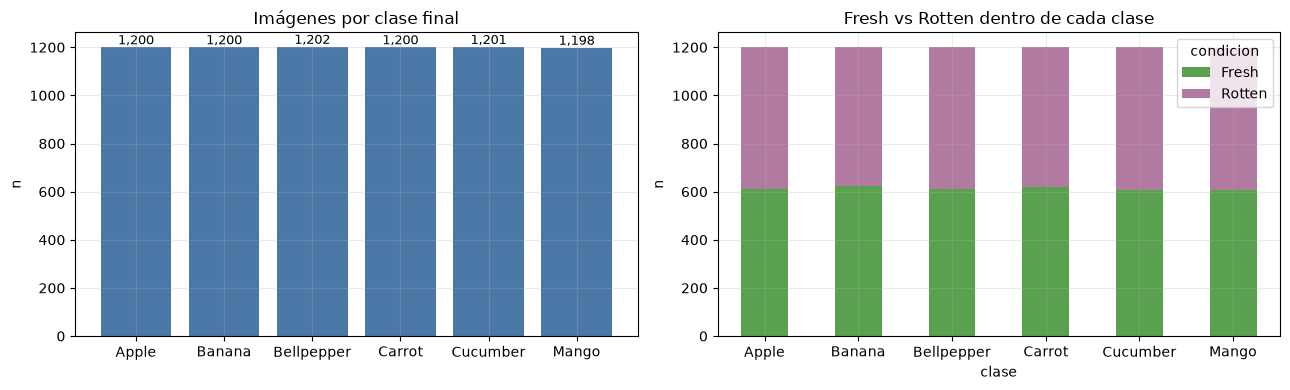

**Resultado.** La clase mayor (Bellpepper, 1,202) y la menor (Mango, 1,198) difieren por un factor de **1.003**. La proporción Fresh/Rotten global es 51.1 % / 48.9 %.

**Interpretación e implicaciones.** El dataset está prácticamente balanceado: **no se requieren pesos de clase ni remuestreo**, y *accuracy* es una métrica válida junto con F1 macro. Como Fresh y Rotten aparecen en proporciones similares dentro de cada clase, el análisis complementario de la sección 23 no estará sesgado por tamaños de muestra muy distintos.

In [ ]:
t2 = df.groupby("clase").size().rename("Número total").to_frame()
t2["%"] = (100 * t2["Número total"] / t2["Número total"].sum()).round(2)
t2.loc["TOTAL"] = [t2["Número total"].sum(), 100.0]
print("Tabla 2 – Clase final | Número total"); display(t2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
conteo = df.groupby("clase").size().reindex(CLASSES)
ax[0].bar(conteo.index, conteo.values, color="#4C78A8")
ax[0].set_title("Imágenes por clase final"); ax[0].set_ylabel("n")
for i, v in enumerate(conteo.values): ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
fr = df.pivot_table(index="clase", columns="condicion", values="ruta", aggfunc="count").reindex(CLASSES)
fr.plot(kind="bar", stacked=True, ax=ax[1], color=["#59A14F", "#B07AA1"], rot=0)
ax[1].set_title("Fresh vs Rotten dentro de cada clase"); ax[1].set_ylabel("n")
plt.tight_layout(); savefig("05_distribucion"); plt.show()

razon = conteo.max() / conteo.min()
md(f"""**Resultado.** La clase mayor ({conteo.idxmax()}, {conteo.max():,}) y la menor ({conteo.idxmin()}, {conteo.min():,}) difieren por un factor de **{razon:.3f}**. La proporción Fresh/Rotten global es {100*(df.condicion=='Fresh').mean():.1f} % / {100*(df.condicion=='Rotten').mean():.1f} %.

**Interpretación e implicaciones.** {'El dataset está prácticamente balanceado: **no se requieren pesos de clase ni remuestreo**, y *accuracy* es una métrica válida junto con F1 macro.' if razon < 1.2 else 'Existe desbalance apreciable: conviene priorizar F1 macro y valorar pesos de clase.'} Como Fresh y Rotten aparecen en proporciones similares dentro de cada clase, el análisis complementario de la sección 23 no estará sesgado por tamaños de muestra muy distintos.""")

# 06. Exploración visual

**Qué se hará:** (1) mostrar ejemplos Fresh y Rotten de cada clase; (2) cuantificar color, brillo, textura y fondo con descriptores simples sobre una muestra; (3) medir la similitud entre clases con histogramas de color.

**Por qué:** entender qué señales visuales distinguen las clases orienta el diseño de la augmentation y permite anticipar dónde se confundirá el modelo.

**Qué esperamos (hipótesis a priori, se contrastarán con la matriz de confusión):**
- Las tres frutas y el pimiento comparten **forma redondeada y colores cálidos** (rojo/amarillo/verde), por lo que *Apple, Mango y Bellpepper* podrían confundirse entre sí.
- *Carrot* y *Cucumber* son alargados y de colores muy distintos; *Banana* también es alargada y amarilla.
- Cuando el producto está **Rotten**, el color se oscurece y la textura cambia: *Banana, Mango y Apple podridos* pueden converger a tonos marrones/negros y perder rasgos de forma.

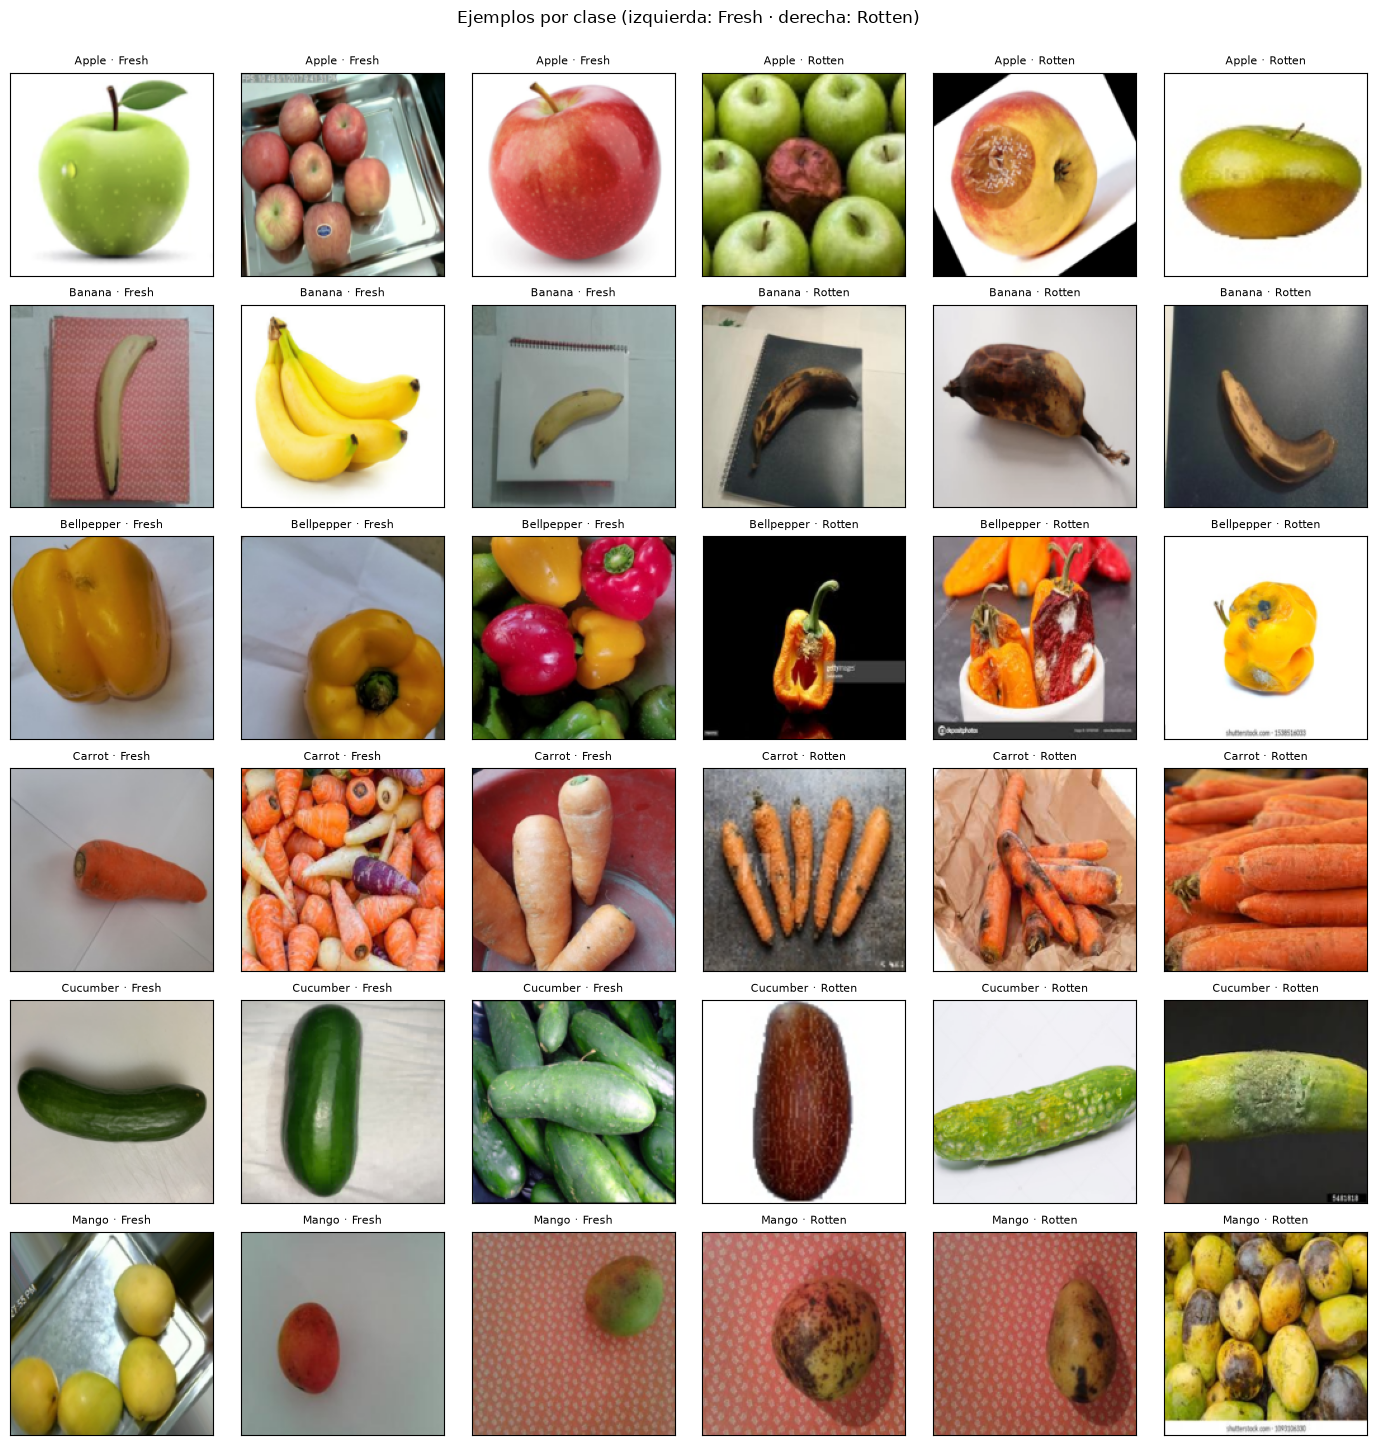

In [ ]:
# 1) Cuadrícula: por clase, 3 Fresh + 3 Rotten
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(14, 2.4 * len(CLASSES)))
for i, c in enumerate(CLASSES):
    for j, cond in enumerate(["Fresh"] * 3 + ["Rotten"] * 3):
        sub = df_ok[(df_ok.clase == c) & (df_ok.condicion == cond)]
        fila = sub.sample(3, random_state=SEED).iloc[j % 3]
        axes[i, j].imshow(load_rgb(fila.ruta, (160, 160)))
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([]); axes[i, j].grid(False)
        axes[i, j].set_title(f"{c} · {cond}", fontsize=8)
plt.suptitle("Ejemplos por clase (izquierda: Fresh · derecha: Rotten)", y=1.0)
plt.tight_layout(); savefig("06_ejemplos"); plt.show()

Descriptores:   0%|          | 0/480 [00:00<?, ?it/s]

Descriptores:   4%|▍         | 18/480 [00:00<00:02, 172.84it/s]

Descriptores:   8%|▊         | 40/480 [00:00<00:02, 184.73it/s]

Descriptores:  13%|█▎        | 63/480 [00:00<00:02, 195.72it/s]

Descriptores:  18%|█▊        | 88/480 [00:00<00:01, 213.95it/s]

...

Descriptores:  90%|█████████ | 434/480 [00:02<00:00, 220.54it/s]

Descriptores:  96%|█████████▌| 459/480 [00:02<00:00, 217.91it/s]

Descriptores: 100%|██████████| 480/480 [00:02<00:00, 199.06it/s]

Descriptores medios (muestra de hasta 40 imágenes por clase y condición):


R      G      B  Saturacion  Brillo  Contraste  \
clase      condicion                                                       
Apple      Fresh      0.562  0.502  0.456       0.290   0.588      0.231   
           Rotten     0.699  0.593  0.492       0.326   0.705      0.270   
Banana     Fresh      0.560  0.543  0.458       0.261   0.586      0.174   
           Rotten     0.606  0.576  0.544       0.174   0.620      0.262   
Bellpepper Fresh      0.537  0.447  0.305       0.549   0.580      0.210   
           Rotten     0.702  0.620  0.506       0.364   0.730      0.178   
Carrot     Fresh      0.630  0.428  0.345       0.482   0.641      0.192   
           Rotten     0.729  0.585  0.502       0.347   0.737      0.162   
Cucumber   Fresh      0.557  0.597  0.488       0.297   0.613      0.229   
           Rotten     0.700  0.672  0.605       0.251   0.715      0.255   
Mango      Fresh      0.554  0.466  0.404       0.322   0.576      0.137   
           Rotten     0.589  0.436  0.368       0.388   0.600      0.169   

                      Textura  Fondo_claro  
clase      condicion                        
Apple      Fresh        0.037        0.264  
           Rotten       0.028        0.499  
Banana     Fresh        0.024        0.083  
           Rotten       0.022        0.311  
Bellpepper Fresh        0.027        0.105  
           Rotten       0.027        0.420  
Carrot     Fresh        0.032        0.102  
           Rotten       0.032        0.313  
Cucumber   Fresh        0.027        0.080  
           Rotten       0.029        0.643  
Mango      Fresh        0.021        0.029  
           Rotten       0.021        0.066

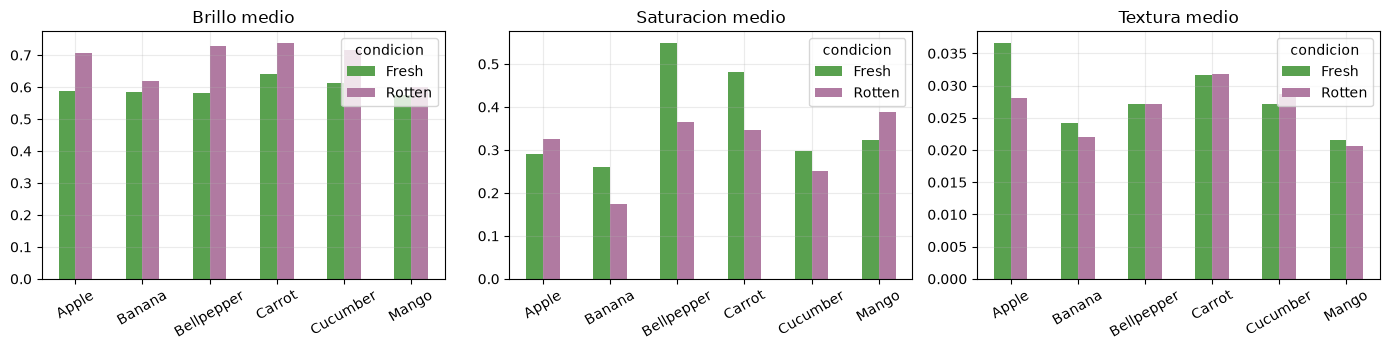

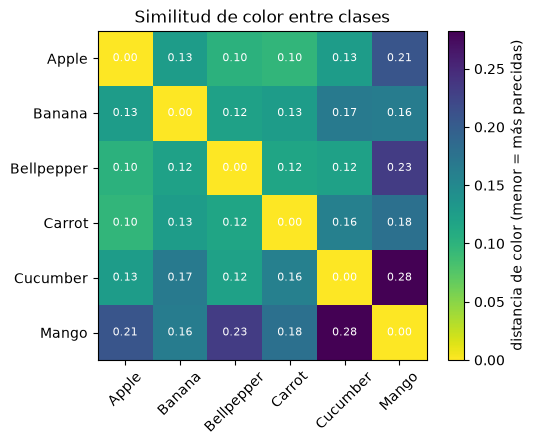

**Resultado.** Según la distancia entre histogramas de color, los pares **más parecidos** son **Apple–Carrot** (0.097), **Apple–Bellpepper** (0.101) y **Bellpepper–Carrot** (0.117); los más distintos son **Cucumber–Mango** (0.283).

**Interpretación.**
- **Color/iluminación:** la clase más brillante es **Carrot** (0.69) y la más oscura **Mango** (0.59); la más saturada es **Bellpepper**. La mayor caída de brillo al pasar de Fresh a Rotten ocurre en **Mango** (Δ = -0.024); no hay un oscurecimiento sistemático al pudrirse.
- **Textura:** la clase con más detalle de bordes/superficie es **Apple** y la más lisa **Mango**.
- **Fondo:** la fracción de borde casi blanco varía de 5% (**Mango**) a 38% (**Apple**): si el fondo difiere mucho entre clases, la red podría aprender el fondo en lugar del objeto (riesgo de *atajo*, que se examina en la sección 08).
- **Forma y orientación:** verifíquese en la cuadrícula superior si los objetos aparecen centrados, en distintas posiciones y con orientaciones variables; esto motiva rotaciones y traslaciones moderadas y *flip* horizontal.

**Implicaciones.** Los pares de color más similares son los candidatos a confusión; se contrastarán con la matriz de confusión (sección 21). Las diferencias Fresh/Rotten dentro de una misma clase justifican tratarlas como variabilidad interna que la CNN debe absorber.

In [ ]:
# 2) Descriptores visuales sobre una muestra estratificada (clase × condición)
N_MUESTRA = 40
def descriptores_visuales(path):
    a = load_rgb(path, (96, 96)).astype(np.float32) / 255.0
    hsv = rgb_to_hsv(a)
    gris = a.mean(axis=2)
    textura = (np.abs(np.diff(gris, axis=1)).mean() + np.abs(np.diff(gris, axis=0)).mean()) / 2
    borde = np.concatenate([a[:8].reshape(-1, 3), a[-8:].reshape(-1, 3),
                            a[:, :8].reshape(-1, 3), a[:, -8:].reshape(-1, 3)])
    hist = np.concatenate([np.histogram(a[..., c], bins=16, range=(0, 1))[0] for c in range(3)]).astype(np.float32)
    hist /= hist.sum()
    d = dict(R=a[..., 0].mean(), G=a[..., 1].mean(), B=a[..., 2].mean(),
             Saturacion=hsv[..., 1].mean(), Brillo=hsv[..., 2].mean(), Contraste=hsv[..., 2].std(),
             Textura=textura, Fondo_claro=(borde.min(axis=1) > 0.85).mean())
    return d, hist

muestra = pd.concat([g.sample(min(N_MUESTRA, len(g)), random_state=SEED)
                     for _, g in df_ok.groupby(["clase", "condicion"])]).reset_index(drop=True)
with ThreadPoolExecutor(N_WORKERS) as ex:
    salida = list(tqdm(ex.map(descriptores_visuales, muestra.ruta), total=len(muestra), desc="Descriptores"))
desc = pd.DataFrame([s[0] for s in salida]); hists = np.stack([s[1] for s in salida])
desc = pd.concat([muestra[["clase", "condicion"]], desc], axis=1)

tabla_desc = desc.groupby(["clase", "condicion"]).mean().round(3)
print(f"Descriptores medios (muestra de hasta {N_MUESTRA} imágenes por clase y condición):")
display(tabla_desc)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a_, col in zip(ax, ["Brillo", "Saturacion", "Textura"]):
    desc.pivot_table(index="clase", columns="condicion", values=col).reindex(CLASSES).plot(
        kind="bar", ax=a_, color=["#59A14F", "#B07AA1"], rot=30)
    a_.set_title(f"{col} medio"); a_.set_xlabel("")
plt.tight_layout(); savefig("06_descriptores"); plt.show()

# 3) Similitud entre clases: distancia L1 entre histogramas de color medios
H = np.stack([hists[(desc.clase == c).values].mean(axis=0) for c in CLASSES])
D = np.abs(H[:, None, :] - H[None, :, :]).sum(axis=2) / 3      # 0 = idénticos
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(D, cmap="viridis_r"); ax.grid(False)
ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45); ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASSES)
for i in range(N_CLASSES):
    for j in range(N_CLASSES): ax.text(j, i, f"{D[i,j]:.2f}", ha="center", va="center", color="w", fontsize=8)
plt.colorbar(im, label="distancia de color (menor = más parecidas)"); ax.set_title("Similitud de color entre clases")
plt.tight_layout(); savefig("06_similitud_color"); plt.show()

pares = sorted([(D[i, j], CLASSES[i], CLASSES[j]) for i in range(N_CLASSES) for j in range(i + 1, N_CLASSES)])
cd = desc.groupby("clase")[["Brillo", "Saturacion", "Textura", "Fondo_claro"]].mean()
dv = desc.pivot_table(index="clase", columns="condicion", values="Brillo"); dv["Δ"] = dv["Fresh"] - dv["Rotten"]
md(f"""**Resultado.** Según la distancia entre histogramas de color, los pares **más parecidos** son **{pares[0][1]}–{pares[0][2]}** ({pares[0][0]:.3f}), **{pares[1][1]}–{pares[1][2]}** ({pares[1][0]:.3f}) y **{pares[2][1]}–{pares[2][2]}** ({pares[2][0]:.3f}); los más distintos son **{pares[-1][1]}–{pares[-1][2]}** ({pares[-1][0]:.3f}).

**Interpretación.**
- **Color/iluminación:** la clase más brillante es **{cd.Brillo.idxmax()}** ({cd.Brillo.max():.2f}) y la más oscura **{cd.Brillo.idxmin()}** ({cd.Brillo.min():.2f}); la más saturada es **{cd.Saturacion.idxmax()}**. La mayor caída de brillo al pasar de Fresh a Rotten ocurre en **{dv['Δ'].idxmax()}** (Δ = {dv['Δ'].max():+.3f}); {'los productos podridos tienden a ser más oscuros.' if (dv['Δ']>0).mean() >= 0.5 else 'no hay un oscurecimiento sistemático al pudrirse.'}
- **Textura:** la clase con más detalle de bordes/superficie es **{cd.Textura.idxmax()}** y la más lisa **{cd.Textura.idxmin()}**.
- **Fondo:** la fracción de borde casi blanco varía de {cd.Fondo_claro.min():.0%} (**{cd.Fondo_claro.idxmin()}**) a {cd.Fondo_claro.max():.0%} (**{cd.Fondo_claro.idxmax()}**): si el fondo difiere mucho entre clases, la red podría aprender el fondo en lugar del objeto (riesgo de *atajo*, que se examina en la sección 08).
- **Forma y orientación:** verifíquese en la cuadrícula superior si los objetos aparecen centrados, en distintas posiciones y con orientaciones variables; esto motiva rotaciones y traslaciones moderadas y *flip* horizontal.

**Implicaciones.** Los pares de color más similares son los candidatos a confusión; se contrastarán con la matriz de confusión (sección 21). Las diferencias Fresh/Rotten dentro de una misma clase justifican tratarlas como variabilidad interna que la CNN debe absorber.""")

# 07. Mapeo Fresh/Rotten → clase final

**Qué se hará:** aplicar `CLASS_MAPPING` al manifiesto, crear la etiqueta numérica `y` y conservar `condicion` (Fresh/Rotten) como **metadato**.

**Por qué:** la consigna pide reconocer el producto. Convertir Fresh/Rotten en 12 clases cambiaría el problema y penalizaría al modelo por distinguir estados, no productos.

**Qué esperamos:** 12 carpetas → 6 clases, sin copiar ninguna imagen: el mapeo es una **columna** del DataFrame, no una reorganización en disco.

In [ ]:
df_ok["y"] = df_ok["clase"].map(CLASS_TO_ID).astype(np.int32)
df_ok["grupo"] = df_ok["clase"].map(GRUPO)

mapeo = (df_ok.groupby(["carpeta", "clase", "grupo", "condicion"]).size().rename("imágenes").reset_index()
              .sort_values(["clase", "condicion"]))
display(mapeo)
assert set(df_ok["clase"]) == set(CLASSES) and df_ok["carpeta"].nunique() == 12
assert (df_ok["carpeta"].map(CLASS_MAPPING) == df_ok["clase"]).all()
print("Verificación: 12 carpetas → 6 clases; ninguna imagen fue copiada ni movida.")
print("Id de clase:", CLASS_TO_ID)
print("Grupos:", {g: [c for c in CLASSES if GRUPO[c] == g] for g in ["Fruta", "Vegetal"]})
md("""**Resultado e interpretación.** Cada una de las 12 carpetas se asigna a exactamente una de las 6 clases y la información de estado permanece en la columna `condicion`. **Implicación:** el modelo se entrena con 6 salidas (softmax); `condicion` solo se usará para estratificar la partición y para el análisis de la sección 23.""")

,carpeta,clase,grupo,condicion,imágenes
0,FreshApple,Apple,Fruta,Fresh,612
6,RottenApple,Apple,Fruta,Rotten,588
1,FreshBanana,Banana,Fruta,Fresh,624
7,RottenBanana,Banana,Fruta,Rotten,576
2,FreshBellpepper,Bellpepper,Vegetal,Fresh,611
8,RottenBellpepper,Bellpepper,Vegetal,Rotten,591
3,FreshCarrot,Carrot,Vegetal,Fresh,620
9,RottenCarrot,Carrot,Vegetal,Rotten,580
4,FreshCucumber,Cucumber,Vegetal,Fresh,608
10,RottenCucumber,Cucumber,Vegetal,Rotten,593


Verificación: 12 carpetas → 6 clases; ninguna imagen fue copiada ni movida.
Id de clase: {'Apple': 0, 'Banana': 1, 'Bellpepper': 2, 'Carrot': 3, 'Cucumber': 4, 'Mango': 5}
Grupos: {'Fruta': ['Apple', 'Banana', 'Mango'], 'Vegetal': ['Bellpepper', 'Carrot', 'Cucumber']}


**Resultado e interpretación.** Cada una de las 12 carpetas se asigna a exactamente una de las 6 clases y la información de estado permanece en la columna `condicion`. **Implicación:** el modelo se entrena con 6 salidas (softmax); `condicion` solo se usará para estratificar la partición y para el análisis de la sección 23.

# 08. Train / Validation / Test

**Qué se hará:** (1) eliminar duplicados exactos conservando una copia; (2) dividir 70 % / 15 % / 15 % con `SEED = 42`, **estratificando por clase × condición**; (3) verificar que no hay *leakage*; (4) probar si los **metadatos** (tamaño/formato) predicen la clase, lo que delataría un atajo.

**Por qué:** los duplicados entre particiones inflan las métricas de Test. La estratificación por clase y estado mantiene la misma composición en las tres particiones.

**Qué esperamos:** ~7 000 imágenes únicas repartidas ≈ 4 900 / 1 050 / 1 050, sin intersección de rutas ni de hashes, y un clasificador basado solo en metadatos con desempeño cercano al azar (si no, hay señal espuria).

In [ ]:
n_antes = len(df_ok)
if CHECK_DUPLICATES and df_ok["md5"].notna().all():
    df_u = df_ok.sort_values("ruta").drop_duplicates("md5", keep="first").reset_index(drop=True)
else:
    df_u = df_ok.sort_values("ruta").reset_index(drop=True)
    print("AVISO: no hay hashes; no se eliminaron duplicados.")
print(f"Imágenes antes de deduplicar: {n_antes:,} | únicas: {len(df_u):,} | eliminadas: {n_antes-len(df_u):,}")
df_u["estrato"] = df_u["clase"] + "_" + df_u["condicion"]

idx_all = df_u.index.to_numpy()
idx_train, idx_tmp = train_test_split(idx_all, test_size=VAL_FRAC + TEST_FRAC, stratify=df_u["estrato"], random_state=SEED)
idx_val, idx_test = train_test_split(idx_tmp, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
                                     stratify=df_u.loc[idx_tmp, "estrato"], random_state=SEED)
idx_train, idx_val, idx_test = np.sort(idx_train), np.sort(idx_val), np.sort(idx_test)
df_u["split"] = "train"; df_u.loc[idx_val, "split"] = "val"; df_u.loc[idx_test, "split"] = "test"

# ── verificación anti-leakage ──
S = {n: set(df_u.loc[i, "ruta"]) for n, i in [("train", idx_train), ("val", idx_val), ("test", idx_test)]}
M = {n: set(df_u.loc[i, "md5"]) for n, i in [("train", idx_train), ("val", idx_val), ("test", idx_test)]} if CHECK_DUPLICATES else None
assert len(idx_train) + len(idx_val) + len(idx_test) == len(df_u)
assert not (S["train"] & S["val"]) and not (S["train"] & S["test"]) and not (S["val"] & S["test"]), "Rutas repetidas entre particiones"
if M:
    assert not (M["train"] & M["val"]) and not (M["train"] & M["test"]) and not (M["val"] & M["test"]), "Contenido repetido entre particiones"
print("Sin intersección de rutas ni de contenido (MD5) entre Train, Val y Test → sin data leakage por duplicados.")

tab_split = pd.crosstab(df_u["clase"], df_u["split"])[["train", "val", "test"]]
tab_split.loc["TOTAL"] = tab_split.sum()
print("\nImágenes por clase y partición:"); display(tab_split)
tab_cond = pd.crosstab(df_u["split"], df_u["condicion"], normalize="index").loc[["train", "val", "test"]].round(3)
print("Proporción Fresh/Rotten por partición:"); display(tab_cond)

Imágenes antes de deduplicar: 7,201 | únicas: 7,019 | eliminadas: 182


Sin intersección de rutas ni de contenido (MD5) entre Train, Val y Test → sin data leakage por duplicados.

Imágenes por clase y partición:


split,train,val,test
clase,,,
Apple,834,179,179
Banana,839,180,180
Bellpepper,803,172,172
Carrot,781,168,167
Cucumber,817,174,176
Mango,839,180,179
TOTAL,4913,1053,1053


Proporción Fresh/Rotten por partición:


condicion,Fresh,Rotten
split,,
train,0.518,0.482
val,0.519,0.481
test,0.517,0.483


In [ ]:
# Prueba de atajo: ¿predicen los METADATOS (tamaño, formato, modo) la clase? Se entrena SOLO con Train.
meta = pd.DataFrame({"w": df_u.w, "h": df_u.h, "aspecto": df_u.w / df_u.h, "pixeles": df_u.w * df_u.h,
                     "ext": df_u.ext.astype("category").cat.codes, "modo": df_u.modo.astype("category").cat.codes})
arbol = DecisionTreeClassifier(max_depth=6, random_state=SEED).fit(meta.loc[idx_train], df_u.loc[idx_train, "y"])
acc_meta = accuracy_score(df_u.loc[idx_val, "y"], arbol.predict(meta.loc[idx_val]))
azar = df_u.loc[idx_train, "y"].value_counts(normalize=True).max()
print(f"Accuracy en Validation usando solo metadatos: {acc_meta:.3f} (azar ≈ {azar:.3f})")

md(f"""**Resultado.** Tras eliminar {n_antes-len(df_u):,} duplicados quedan **{len(df_u):,}** imágenes únicas: **{len(idx_train):,} Train ({len(idx_train)/len(df_u):.1%})**, **{len(idx_val):,} Validation ({len(idx_val)/len(df_u):.1%})** y **{len(idx_test):,} Test ({len(idx_test)/len(df_u):.1%})**. Las comprobaciones de rutas y de hash no encontraron ninguna imagen en más de una partición.

**Interpretación.** La estratificación por clase × condición mantiene la composición casi idéntica en las tres particiones, de modo que las diferencias de desempeño no se deberán a un reparto desigual. Un árbol de decisión que solo ve tamaño/formato alcanza **{acc_meta:.1%}** frente a un azar de {azar:.1%}: {'**existe señal en los metadatos** (p. ej. clases provenientes de fuentes con distinta resolución). La CNN podría aprovechar atajos como fondo o encuadre; se debe interpretar su accuracy con cautela y se documenta como limitación.' if acc_meta > azar + 0.15 else 'los metadatos aportan poca información, lo que reduce el riesgo de que la red aprenda por atajos de formato.'}

**Implicaciones.** *Test* permanece intacto hasta la evaluación final: no se usa para elegir hiperparámetros ni para *early stopping*. Todas las decisiones de entrenamiento se toman con *Validation*.""")

Accuracy en Validation usando solo metadatos: 0.445 (azar ≈ 0.171)


**Resultado.** Tras eliminar 182 duplicados quedan **7,019** imágenes únicas: **4,913 Train (70.0%)**, **1,053 Validation (15.0%)** y **1,053 Test (15.0%)**. Las comprobaciones de rutas y de hash no encontraron ninguna imagen en más de una partición.

**Interpretación.** La estratificación por clase × condición mantiene la composición casi idéntica en las tres particiones, de modo que las diferencias de desempeño no se deberán a un reparto desigual. Un árbol de decisión que solo ve tamaño/formato alcanza **44.5%** frente a un azar de 17.1%: **existe señal en los metadatos** (p. ej. clases provenientes de fuentes con distinta resolución). La CNN podría aprovechar atajos como fondo o encuadre; se debe interpretar su accuracy con cautela y se documenta como limitación.

**Implicaciones.** *Test* permanece intacto hasta la evaluación final: no se usa para elegir hiperparámetros ni para *early stopping*. Todas las decisiones de entrenamiento se toman con *Validation*.

# 09. Preprocesamiento

**Qué se hará:** convertir cada imagen única a **RGB 128×128** (una sola vez), guardarla en un archivo `.npy` (`uint8`) y leerla con `memmap`; construir pipelines `tf.data` que **normalizan 0–255 → 0–1** al vuelo.

**Por qué RGB y no escala de grises:** el color es la señal más discriminante del problema (verde/naranja/amarillo/rojo; marrón al pudrirse). En gris se perdería la distinción, por ejemplo, entre un pepino y un pimiento verde de luminancia similar, y el estado Fresh/Rotten se apoya en el color. El costo de RGB (3 canales) solo afecta la primera capa convolucional.

**Por qué caché + memmap:** las imágenes originales llegan a 6 183×4 345 px; decodificarlas en cada época, para tres modelos y en CPU, sería muy lento. Se decodifican una vez y no se duplican archivos en disco (solo un array compacto de ~350 MB). Con `memmap` los datos **no se cargan completos en RAM**.

**Qué esperamos:** array de forma `(N, 128, 128, 3)`, valores 0–255 en el caché y 0–1 tras normalizar.

> El redimensionado es directo a 128×128: en imágenes no cuadradas distorsiona ligeramente la relación de aspecto (limitación documentada).

In [ ]:
N = len(df_u)
CACHE_NPY = CACHE_DIR / f"imagenes_{IMG_SIZE[0]}x{IMG_SIZE[1]}.npy"
CACHE_META = CACHE_DIR / f"imagenes_{IMG_SIZE[0]}x{IMG_SIZE[1]}.json"
clave = hashlib.md5("|".join(df_u["ruta"]).encode()).hexdigest()

def cache_valido():
    if not (CACHE_NPY.exists() and CACHE_META.exists()): return False
    m = json.loads(CACHE_META.read_text())
    return m.get("clave") == clave and m.get("n") == N and tuple(m.get("img_size")) == tuple(IMG_SIZE)

if REBUILD_CACHE or not cache_valido():
    t0 = time.time()
    Xw = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.uint8, shape=(N, *IMG_SIZE, N_CHANNELS))
    def cargar(i):
        Xw[i] = load_rgb(df_u.ruta[i], IMG_SIZE); return i
    with ThreadPoolExecutor(N_WORKERS) as ex:
        list(tqdm(ex.map(cargar, range(N)), total=N, desc="Generando caché"))
    Xw.flush(); del Xw
    CACHE_META.write_text(json.dumps({"clave": clave, "n": N, "img_size": list(IMG_SIZE)}))
    print(f"Caché generado en {time.time()-t0:.0f} s")
else:
    print("Caché válido: se reutiliza.")

X = np.load(CACHE_NPY, mmap_mode="r")
Y = df_u["y"].to_numpy().astype(np.int32)
assert X.shape == (N, *IMG_SIZE, N_CHANNELS) and X.dtype == np.uint8
print("X:", X.shape, X.dtype, f"| tamaño en disco ≈ {CACHE_NPY.stat().st_size/1e6:.0f} MB | carga en RAM: solo bajo demanda (memmap)")
mm = np.asarray(X[np.sort(np.random.default_rng(SEED).choice(N, min(200, N), replace=False))])
print(f"Rango de píxeles (muestra): {mm.min()}–{mm.max()} → tras /255: {mm.min()/255:.2f}–{mm.max()/255:.2f}")

AUTOTUNE = tf.data.AUTOTUNE
def normalizar(x, y):
    return tf.cast(x, tf.float32) / 255.0, y          # 0–255 → 0–1

def crear_dataset(indices, entrenamiento=False, augment=False, batch_size=BATCH_SIZE):
    """Pipeline tf.data desde el caché. Solo Train (entrenamiento=True) baraja; solo augment=True aplica augmentation."""
    indices = np.asarray(indices)
    rng = np.random.default_rng(SEED)
    def gen():
        orden = rng.permutation(indices) if entrenamiento else indices
        for i in orden:
            yield np.asarray(X[i]), Y[i]
    ds = tf.data.Dataset.from_generator(
        gen, output_signature=(tf.TensorSpec((*IMG_SIZE, N_CHANNELS), tf.uint8), tf.TensorSpec((), tf.int32)))
    ds = ds.map(normalizar, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augmentar, num_parallel_calls=AUTOTUNE)      # `augmentar` se define en la sección 10
    return ds.batch(batch_size).prefetch(AUTOTUNE)

md(f"""**Resultado e interpretación.** El caché contiene las {N:,} imágenes únicas en RGB {IMG_SIZE[0]}×{IMG_SIZE[1]}. El pipeline normaliza a [0, 1] al vuelo y solo el conjunto de **Train** se barajará y (en la sección 10) se aumentará; Validation y Test se leen en orden fijo y sin transformaciones aleatorias. **Implicación:** entrenar tres CNN reutilizará el mismo caché sin volver a decodificar imágenes grandes.""")

Generando caché:   0%|          | 0/7019 [00:00<?, ?it/s]

Generando caché:   1%|          | 48/7019 [00:00<00:15, 450.83it/s]

Generando caché:   2%|▏         | 113/7019 [00:00<00:13, 507.87it/s]

Generando caché:   2%|▏         | 164/7019 [00:00<00:13, 503.55it/s]

Generando caché:   3%|▎         | 215/7019 [00:00<00:16, 418.53it/s]

...

Generando caché:  98%|█████████▊| 6845/7019 [00:16<00:00, 316.82it/s]

Generando caché:  99%|█████████▊| 6924/7019 [00:16<00:00, 379.81it/s]

Generando caché: 100%|██████████| 7019/7019 [00:16<00:00, 430.54it/s]

Caché generado en 18 s
X: (7019, 128, 128, 3) uint8 | tamaño en disco ≈ 345 MB | carga en RAM: solo bajo demanda (memmap)
Rango de píxeles (muestra): 0–255 → tras /255: 0.00–1.00


**Resultado e interpretación.** El caché contiene las 7,019 imágenes únicas en RGB 128×128. El pipeline normaliza a [0, 1] al vuelo y solo el conjunto de **Train** se barajará y (en la sección 10) se aumentará; Validation y Test se leen en orden fijo y sin transformaciones aleatorias. **Implicación:** entrenar tres CNN reutilizará el mismo caché sin volver a decodificar imágenes grandes.

# 10. Data Augmentation

**Qué se hará:** definir transformaciones **aleatorias moderadas** que se aplican **únicamente a Train**, y visualizar *original vs augmentado*.

**Por qué:** con ~4 900 imágenes de entrenamiento, una CNN puede memorizar. La augmentation genera variantes plausibles en cada época, aumentando la diversidad efectiva sin guardar imágenes nuevas en disco. La consigna exige robustez ante cambios de tamaño, rotación e iluminación.

| Transformación | Parámetro | Qué aporta |
|---|---|---|
| Rotación | ±18° | Invarianza a la orientación del objeto en la foto |
| Traslación | ±10 % | Invarianza a la posición (objeto no centrado) |
| Zoom | ±10 % | Robustez a la distancia/escala de captura |
| Flip horizontal | 50 % | Duplica configuraciones sin alterar la semántica (no se usa flip vertical) |
| Brillo | ±0.10 | Robustez a distintas condiciones de iluminación |
| Contraste | ×0.85–1.15 | Robustez a exposición y cámara |
| Ruido gaussiano | σ = 0.02 | Robustez a ruido de sensor y compresión |

**Qué esperamos:** imágenes reconocibles (sin transformaciones exageradas) y **ninguna** augmentation en Validation/Test.

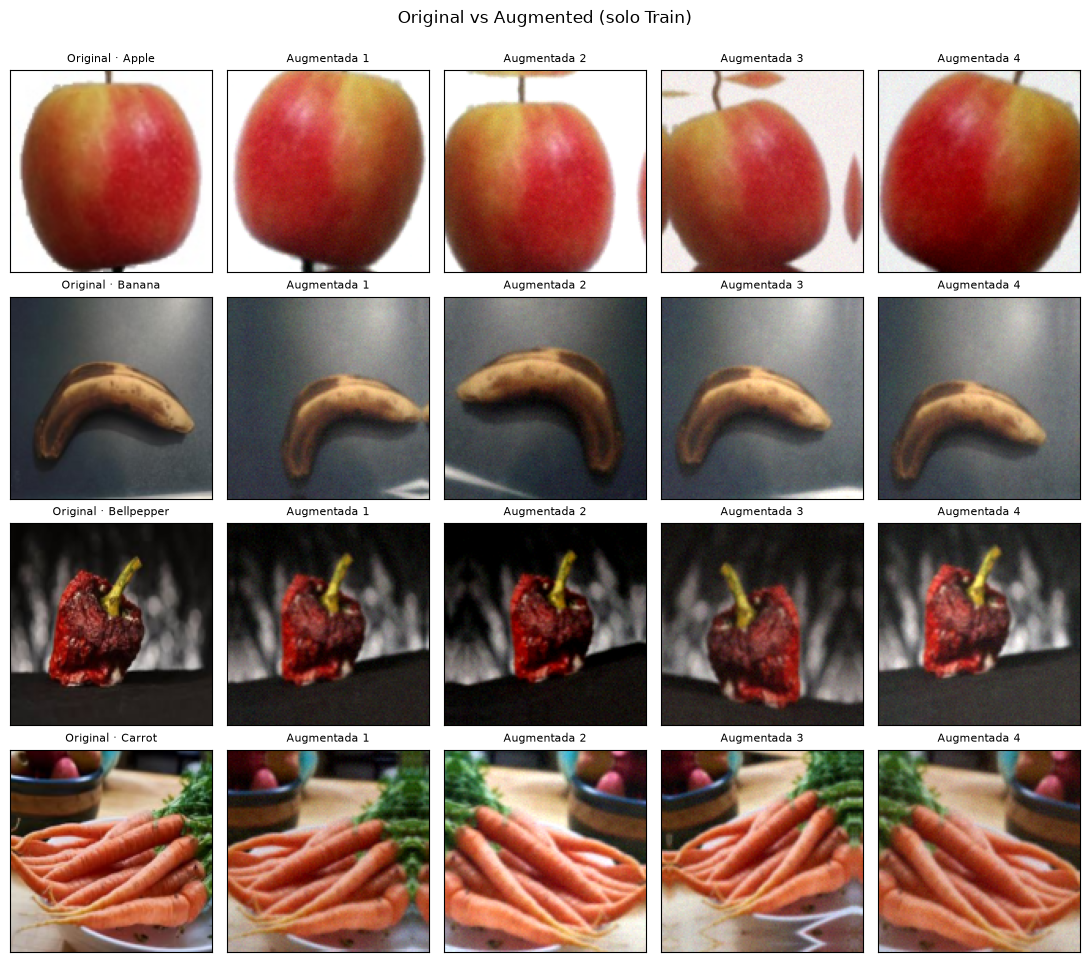

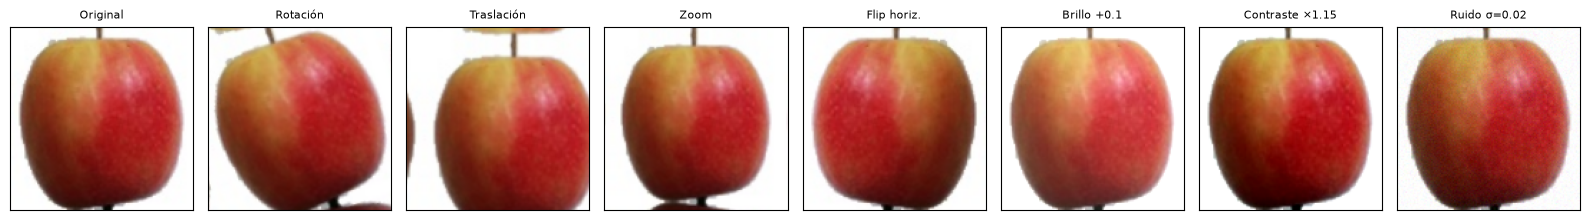

Validation determinista entre lecturas: True | Train aleatorio entre lecturas: True


Lote de Train: (32, 128, 128, 3), rango [0.00, 1.00]


**Resultado e interpretación.** Las variantes conservan la identidad visual del producto; las transformaciones son moderadas (sin rotaciones extremas, sin flip vertical, ruido leve). La verificación confirma que **Validation/Test se leen de forma determinista** y solo Train varía entre lecturas. **Implicación:** la red verá una versión ligeramente distinta de cada imagen en cada época, lo que actúa como regularizador; todas las arquitecturas usan exactamente la misma augmentation, de modo que las diferencias entre ellas no se deben a este factor.

In [ ]:
AUG = dict(rotacion=0.05, traslacion=0.10, zoom=0.10, brillo=0.10, contraste=(0.85, 1.15), ruido=0.02)   # rotación: fracción de 2π → ±18°

capa_flip = layers.RandomFlip("horizontal", seed=SEED)
capa_rot = layers.RandomRotation(AUG["rotacion"], fill_mode="reflect", seed=SEED)
capa_tras = layers.RandomTranslation(AUG["traslacion"], AUG["traslacion"], fill_mode="reflect", seed=SEED)
capa_zoom = layers.RandomZoom(AUG["zoom"], fill_mode="reflect", seed=SEED)

def t_geometria(x):
    x = capa_flip(x, training=True); x = capa_rot(x, training=True)
    x = capa_tras(x, training=True); return capa_zoom(x, training=True)

def t_fotometria(x):
    x = tf.image.random_brightness(x, AUG["brillo"])
    x = tf.image.random_contrast(x, *AUG["contraste"])
    x = x + tf.random.normal(tf.shape(x), stddev=AUG["ruido"])
    return x

def augmentar(x, y):
    """Augmentation completa (solo para el dataset de Train). x en [0,1]."""
    x = t_geometria(x); x = t_fotometria(x)
    return tf.clip_by_value(x, 0.0, 1.0), y

# ── Visualización 1: original vs 4 versiones aumentadas ──
rng = np.random.default_rng(SEED)
ejemplos = [rng.choice(idx_train[df_u.loc[idx_train, "clase"].values == c]) for c in CLASSES[:4]]
fig, axes = plt.subplots(len(ejemplos), 5, figsize=(11, 2.4 * len(ejemplos)))
for i, k in enumerate(ejemplos):
    orig = tf.convert_to_tensor(np.asarray(X[k]).astype(np.float32) / 255.0)
    axes[i, 0].imshow(orig.numpy()); axes[i, 0].set_title(f"Original · {df_u.clase[k]}", fontsize=8)
    for j in range(1, 5):
        axes[i, j].imshow(augmentar(orig, 0)[0].numpy()); axes[i, j].set_title(f"Augmentada {j}", fontsize=8)
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([]); a.grid(False)
plt.suptitle("Original vs Augmented (solo Train)", y=1.0); plt.tight_layout(); savefig("10_original_vs_aug"); plt.show()

# ── Visualización 2: efecto de cada transformación por separado ──
k = ejemplos[0]; orig = tf.convert_to_tensor(np.asarray(X[k]).astype(np.float32) / 255.0)
solo = {"Original": lambda x: x,
        "Rotación": lambda x: layers.RandomRotation((0.05, 0.05), fill_mode="reflect")(x, training=True),
        "Traslación": lambda x: layers.RandomTranslation((0.1, 0.1), (0.1, 0.1), fill_mode="reflect")(x, training=True),
        "Zoom": lambda x: layers.RandomZoom((0.1, 0.1), fill_mode="reflect")(x, training=True),
        "Flip horiz.": lambda x: tf.image.flip_left_right(x),
        "Brillo +0.1": lambda x: tf.clip_by_value(x + 0.1, 0, 1),
        "Contraste ×1.15": lambda x: tf.clip_by_value(tf.image.adjust_contrast(x, 1.15), 0, 1),
        "Ruido σ=0.02": lambda x: tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=0.02), 0, 1)}
fig, axes = plt.subplots(1, len(solo), figsize=(16, 2.4))
for a, (n, f) in zip(axes, solo.items()):
    a.imshow(f(orig).numpy()); a.set_title(n, fontsize=8); a.set_xticks([]); a.set_yticks([]); a.grid(False)
plt.tight_layout(); savefig("10_transformaciones"); plt.show()

# ── Verificación: solo Train tiene augmentation ──
ds_train = crear_dataset(idx_train, entrenamiento=True, augment=True)
ds_val = crear_dataset(idx_val)
ds_test = crear_dataset(idx_test)
v1 = next(iter(ds_val))[0].numpy(); v2 = next(iter(ds_val))[0].numpy()
val_det = np.array_equal(v1, v2)
tr = [next(iter(ds_train))[0].numpy() for _ in range(2)]
train_alea = not np.array_equal(tr[0], tr[1])
print(f"Validation determinista entre lecturas: {val_det} | Train aleatorio entre lecturas: {train_alea}")
assert val_det and train_alea
xb, yb = next(iter(ds_train))
print(f"Lote de Train: {xb.shape}, rango [{xb.numpy().min():.2f}, {xb.numpy().max():.2f}]")
md("""**Resultado e interpretación.** Las variantes conservan la identidad visual del producto; las transformaciones son moderadas (sin rotaciones extremas, sin flip vertical, ruido leve). La verificación confirma que **Validation/Test se leen de forma determinista** y solo Train varía entre lecturas. **Implicación:** la red verá una versión ligeramente distinta de cada imagen en cada época, lo que actúa como regularizador; todas las arquitecturas usan exactamente la misma augmentation, de modo que las diferencias entre ellas no se deben a este factor.""")

# 11. CNN 1 – Baseline

**Qué se hará:** una CNN sencilla y clásica: 3 bloques `Conv2D + ReLU + MaxPooling` con filtros 32-64-128, luego `Flatten → Dropout(0.5) → Dense(128, ReLU) → Dense(6, Softmax)`.

**Arquitectura y decisiones:**
- **Conv2D 3×3 + ReLU:** extrae bordes → texturas → formas de forma jerárquica; ReLU aporta no linealidad y gradientes estables.
- **MaxPooling 2×2:** reduce la resolución a la mitad y da invarianza local a pequeños desplazamientos.
- **Dropout 0.5** antes de la capa densa: la parte densa concentra la mayoría de parámetros y es donde más se memoriza.
- **Softmax:** distribución de probabilidad sobre las 6 clases.

### ¿Qué esperamos de esta arquitectura?
Un rendimiento **razonable pero limitado**: pocas capas convolucionales capturan color y formas simples, pero pueden costar distinguir clases de aspecto parecido o productos muy deteriorados. Al no tener normalización de lotes, la optimización puede ser más lenta/inestable, y al usar `Flatten` con una capa densa grande tiene **muchos parámetros** (riesgo de sobreajuste, mitigado por Dropout y augmentation). Sirve como **línea base** contra la que medir el aporte de mayor profundidad y de regularización.

In [ ]:
def build_cnn1():
    inp = keras.Input((*IMG_SIZE, N_CHANNELS), name="imagen")
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp); x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x);  x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x); x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN1_Baseline")

def compilar(model):
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

set_seeds(); _m = compilar(build_cnn1()); _m.summary()
md(f"""**Resultado e interpretación.** CNN 1 tiene **{_m.count_params():,}** parámetros; la mayor parte está en la primera capa densa (después de `Flatten`). **Implicación:** es un modelo compacto en cómputo (pocas convoluciones), pero con alta capacidad de memorización en la parte densa.""")

Model: "CNN1_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,454 (16.36 MB)

 Trainable params: 4,288,454 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

**Resultado e interpretación.** CNN 1 tiene **4,288,454** parámetros; la mayor parte está en la primera capa densa (después de `Flatten`). **Implicación:** es un modelo compacto en cómputo (pocas convoluciones), pero con alta capacidad de memorización en la parte densa.

# 12. Entrenamiento CNN 1

**Qué se hará:** entrenar con **Adam** (lr = 1e-3), pérdida *sparse categorical crossentropy* y métrica *accuracy*, con tres *callbacks*: `EarlyStopping` (val_loss, paciencia 6, restaura mejores pesos), `ReduceLROnPlateau` (×0.5, paciencia 3) y `ModelCheckpoint` (guarda el mejor modelo).

**Por qué:** todas las decisiones de parada y de tasa de aprendizaje usan **Validation**; **Test no se toca**. Las tres CNN se entrenan con exactamente las mismas condiciones para que la comparación sea justa.

**Qué esperamos:** convergencia en pocas decenas de épocas; en CPU, cada época puede tardar desde decenas de segundos hasta unos minutos según el equipo. Si los modelos ya fueron entrenados y guardados, se cargan sin reentrenar (`FORCE_RETRAIN = False`).

In [ ]:
def entrenar(nombre, builder):
    ruta_modelo = ARTIFACTS_DIR / "modelos" / f"{nombre}.keras"
    ruta_hist = ARTIFACTS_DIR / "historiales" / f"{nombre}.json"
    if not FORCE_RETRAIN and ruta_modelo.exists() and ruta_hist.exists():
        print(f"[{nombre}] modelo e historial encontrados: se cargan (FORCE_RETRAIN=False).")
        return keras.models.load_model(ruta_modelo), json.loads(ruta_hist.read_text())
    set_seeds(); model = compilar(builder())
    cbs = [callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
           callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
           callbacks.ModelCheckpoint(str(ruta_modelo), monitor="val_loss", save_best_only=True)]
    t0 = time.time()
    h = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS, callbacks=cbs, verbose=2)
    hist = {k: [float(v) for v in vals] for k, vals in h.history.items()}
    hist["tiempo_s"] = time.time() - t0
    ruta_hist.write_text(json.dumps(hist))
    print(f"[{nombre}] entrenado en {hist['tiempo_s']/60:.1f} min, {len(hist['loss'])} épocas.")
    return model, hist

def graficar_historial(hist, nombre):
    ep = np.arange(1, len(hist["loss"]) + 1); mejor = int(np.argmin(hist["val_loss"])) + 1
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].plot(ep, hist["accuracy"], label="Training Accuracy"); ax[0].plot(ep, hist["val_accuracy"], label="Validation Accuracy")
    ax[1].plot(ep, hist["loss"], label="Training Loss"); ax[1].plot(ep, hist["val_loss"], label="Validation Loss")
    for a, t in zip(ax, ["Accuracy", "Loss"]):
        a.axvline(mejor, color="gray", ls="--", lw=1, label=f"mejor época (val_loss) = {mejor}")
        a.set_xlabel("Época"); a.set_title(f"{nombre} – {t}"); a.legend()
    plt.tight_layout(); savefig(f"curvas_{nombre}"); plt.show()

def diagnostico_curvas(hist, nombre):
    b = int(np.argmin(hist["val_loss"]))
    ta, va, tl, vl = hist["accuracy"][b], hist["val_accuracy"][b], hist["loss"][b], hist["val_loss"][b]
    gap = ta - va
    if ta < 0.75 and va < 0.75: dx = "**posible subajuste**: la exactitud es baja incluso en entrenamiento; el modelo podría carecer de capacidad o de épocas."
    elif gap > 0.08: dx = "**sobreajuste apreciable**: el modelo rinde claramente mejor en Train que en Validation."
    elif gap < -0.02: dx = "**Validation supera a Train** durante el entrenamiento: es esperable porque Train usa augmentation y Dropout activos; no indica sobreajuste."
    else: dx = "**generalización adecuada**: Train y Validation están cercanos."
    return (f"**{nombre}** entrenó {len(hist['loss'])} épocas; la mejor (val_loss = {vl:.4f}) fue la **{b+1}**. En esa época: "
            f"Train Acc {ta:.3f} (con augmentation y Dropout activos) vs Val Acc {va:.3f} (diferencia {gap:+.3f}); Train Loss {tl:.3f} vs Val Loss {vl:.3f}. Diagnóstico: {dx}")

models, histories, results = {}, {}, {}
models["CNN1_Baseline"], histories["CNN1_Baseline"] = entrenar("CNN1_Baseline", build_cnn1)

Epoch 1/30


154/154 - 85s - 550ms/step - accuracy: 0.4875 - loss: 1.3257 - val_accuracy: 0.7246 - val_loss: 0.8007 - learning_rate: 0.0010


Epoch 2/30


154/154 - 99s - 642ms/step - accuracy: 0.6819 - loss: 0.8603 - val_accuracy: 0.7692 - val_loss: 0.6872 - learning_rate: 0.0010


Epoch 3/30


...


Epoch 26: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


154/154 - 174s - 1s/step - accuracy: 0.9593 - loss: 0.1103 - val_accuracy: 0.9335 - val_loss: 0.2624 - learning_rate: 1.2500e-04


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 20.


[CNN1_Baseline] entrenado en 50.1 min, 26 épocas.


# 13. Evaluación CNN 1

**Qué se hará:** graficar Training/Validation Accuracy y Loss, y calcular **Accuracy, Precision, Recall y F1** (macro) en Train, Validation y Test, más el `classification_report` en Test.

**Por qué:** las curvas muestran cómo aprende y si sobreajusta; las métricas por clase revelan qué productos se confunden. Train se evalúa **sin augmentation** para que el *Overfitting Gap* (Train − Val) sea comparable.

**Qué esperamos:** una brecha Train–Val moderada y F1 por clase relativamente homogéneo dado el balance.

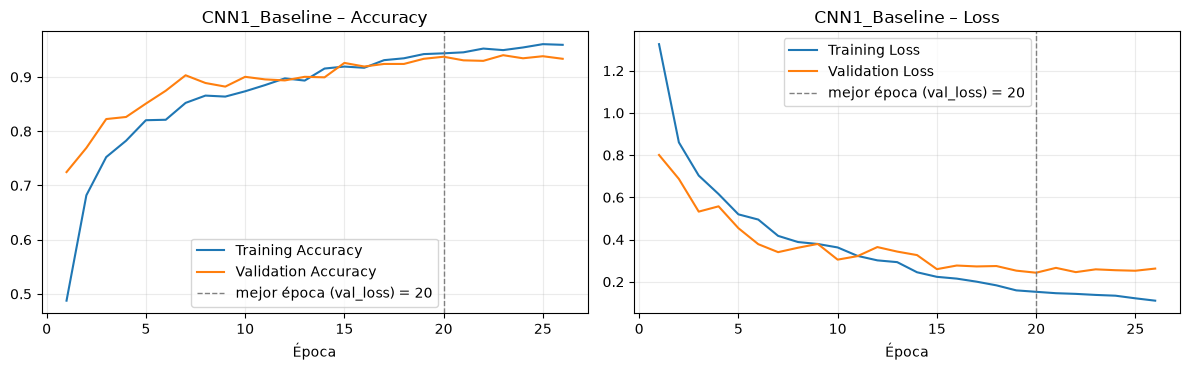

Métricas de CNN1_Baseline:


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
train,0.9764,0.9763,0.9763,0.9763
val,0.9373,0.9374,0.9371,0.9371
test,0.9183,0.9190,0.9181,0.9180


classification_report – Test (CNN1_Baseline):
              precision    recall  f1-score   support

       Apple     0.9222    0.9274    0.9248       179
      Banana     0.9000    0.9500    0.9243       180
  Bellpepper     0.9177    0.8430    0.8788       172
      Carrot     0.9345    0.9401    0.9373       167
    Cucumber     0.8919    0.9375    0.9141       176
       Mango     0.9477    0.9106    0.9288       179

    accuracy                         0.9183      1053
   macro avg     0.9190    0.9181    0.9180      1053
weighted avg     0.9189    0.9183    0.9181      1053



**CNN1_Baseline** entrenó 26 épocas; la mejor (val_loss = 0.2427) fue la **20**. En esa época: Train Acc 0.944 (con augmentation y Dropout activos) vs Val Acc 0.937 (diferencia +0.006); Train Loss 0.152 vs Val Loss 0.243. Diagnóstico: **generalización adecuada**: Train y Validation están cercanos.

**Métricas.** Test: Accuracy **0.9183**, F1 macro **0.9180**. Overfitting Gap (Train−Val, sin augmentation) = **+0.0391**. Clase más difícil en Test: **Bellpepper** (F1 = 0.879); más fácil: **Carrot** (F1 = 0.937).

In [ ]:
def evaluar_modelo(nombre):
    model, hist = models[nombre], histories[nombre]
    r = {"params": model.count_params(), "history": hist}
    for split, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
        probs = model.predict(crear_dataset(idx), verbose=0)
        pred = probs.argmax(axis=1); y = Y[idx]
        p, rc, f, _ = precision_recall_fscore_support(y, pred, average="macro", zero_division=0)
        r[split] = dict(acc=accuracy_score(y, pred), prec=p, rec=rc, f1=f, pred=pred, probs=probs, y=y,
                        f1_clase=f1_score(y, pred, average=None, labels=range(N_CLASSES), zero_division=0))
    results[nombre] = r
    graficar_historial(hist, nombre)
    tab = pd.DataFrame({s: {"Accuracy": r[s]["acc"], "Precision (macro)": r[s]["prec"], "Recall (macro)": r[s]["rec"], "F1 (macro)": r[s]["f1"]}
                        for s in ["train", "val", "test"]}).T.round(4)
    print(f"Métricas de {nombre}:"); display(tab)
    print(f"classification_report – Test ({nombre}):")
    print(classification_report(r["test"]["y"], r["test"]["pred"], target_names=CLASSES, digits=4, zero_division=0))
    md(diagnostico_curvas(hist, nombre) + f"\n\n**Métricas.** Test: Accuracy **{r['test']['acc']:.4f}**, F1 macro **{r['test']['f1']:.4f}**. "
       f"Overfitting Gap (Train−Val, sin augmentation) = **{r['train']['acc']-r['val']['acc']:+.4f}**. "
       f"Clase más difícil en Test: **{CLASSES[int(np.argmin(r['test']['f1_clase']))]}** (F1 = {r['test']['f1_clase'].min():.3f}); "
       f"más fácil: **{CLASSES[int(np.argmax(r['test']['f1_clase']))]}** (F1 = {r['test']['f1_clase'].max():.3f}).")

evaluar_modelo("CNN1_Baseline")

# 14. CNN 2 – Deep CNN

**Qué se hará:** una red **claramente más profunda** (6 convoluciones frente a 3), con **filtros progresivos** 32 → 64 → 128 → 256, **BatchNormalization** después de cada convolución, `Dropout` creciente (0.25 → 0.30) y `Flatten → Dense(256) → Dropout(0.5) → Softmax`.

**Hipótesis:** una red más profunda puede aprender **características visuales más complejas** (texturas de piel, manchas de descomposición, formas compuestas), y BatchNormalization estabiliza y acelera la optimización, lo que permite entrenar con mayor profundidad.

**Qué esperamos:** mejor capacidad de representación que la baseline, convergencia más suave por BatchNorm y mayor costo computacional (más operaciones por imagen). El riesgo es un mayor sobreajuste por su alta capacidad, que Dropout y augmentation deben contener.

In [ ]:
def conv_bn(x, filtros):
    x = layers.Conv2D(filtros, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def build_cnn2():
    inp = keras.Input((*IMG_SIZE, N_CHANNELS), name="imagen")
    x = conv_bn(inp, 32);                       x = layers.MaxPooling2D()(x)                      # 64×64
    x = conv_bn(x, 64);  x = conv_bn(x, 64);    x = layers.MaxPooling2D()(x); x = layers.Dropout(0.25)(x)   # 32×32
    x = conv_bn(x, 128); x = conv_bn(x, 128);   x = layers.MaxPooling2D()(x); x = layers.Dropout(0.30)(x)   # 16×16
    x = conv_bn(x, 256);                        x = layers.MaxPooling2D()(x)                      # 8×8
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x); x = layers.Dropout(0.5)(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN2_Deep")

set_seeds(); _m = compilar(build_cnn2()); _m.summary()
md(f"""**Resultado e interpretación.** CNN 2 tiene **{_m.count_params():,}** parámetros. Aunque su profundidad es el doble, el número de parámetros lo determina sobre todo la capa densa tras `Flatten`. **Implicación:** su costo por imagen es mayor (más convoluciones a resoluciones altas), por lo que el entrenamiento en CPU será notablemente más lento que CNN 1.""")

Model: "CNN2_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,771,046 (18.20 MB)

 Trainable params: 4,769,702 (18.19 MB)

 Non-trainable params: 1,344 (5.25 KB)

**Resultado e interpretación.** CNN 2 tiene **4,771,046** parámetros. Aunque su profundidad es el doble, el número de parámetros lo determina sobre todo la capa densa tras `Flatten`. **Implicación:** su costo por imagen es mayor (más convoluciones a resoluciones altas), por lo que el entrenamiento en CPU será notablemente más lento que CNN 1.

# 15. Entrenamiento CNN 2

**Qué se hará:** entrenar CNN 2 con la **misma configuración** que CNN 1 (Adam, lr = 1e-3, mismos callbacks, misma augmentation, misma semilla).

**Por qué:** cualquier diferencia de resultados debe atribuirse a la arquitectura, no al procedimiento de entrenamiento.

**Qué esperamos:** entrenamiento más lento por época; convergencia posiblemente más rápida en épocas gracias a BatchNorm.

In [ ]:
models["CNN2_Deep"], histories["CNN2_Deep"] = entrenar("CNN2_Deep", build_cnn2)

Epoch 1/30


154/154 - 385s - 2s/step - accuracy: 0.2589 - loss: 2.9885 - val_accuracy: 0.1709 - val_loss: 1.8198 - learning_rate: 0.0010


Epoch 2/30


154/154 - 308s - 2s/step - accuracy: 0.3326 - loss: 1.5777 - val_accuracy: 0.1709 - val_loss: 2.0187 - learning_rate: 0.0010


Epoch 3/30


...

154/154 - 288s - 2s/step - accuracy: 0.6401 - loss: 0.8462 - val_accuracy: 0.8803 - val_loss: 0.3921 - learning_rate: 1.2500e-04


Epoch 30/30


154/154 - 287s - 2s/step - accuracy: 0.6405 - loss: 0.8456 - val_accuracy: 0.8775 - val_loss: 0.3963 - learning_rate: 1.2500e-04


Restoring model weights from the end of the best epoch: 29.


[CNN2_Deep] entrenado en 152.8 min, 30 épocas.


# 16. Evaluación CNN 2

**Qué se hará y por qué:** mismo protocolo de evaluación que CNN 1, para comparabilidad directa.

**Qué esperamos:** mayor exactitud que la baseline si la profundidad aporta; vigilar la brecha Train–Val.

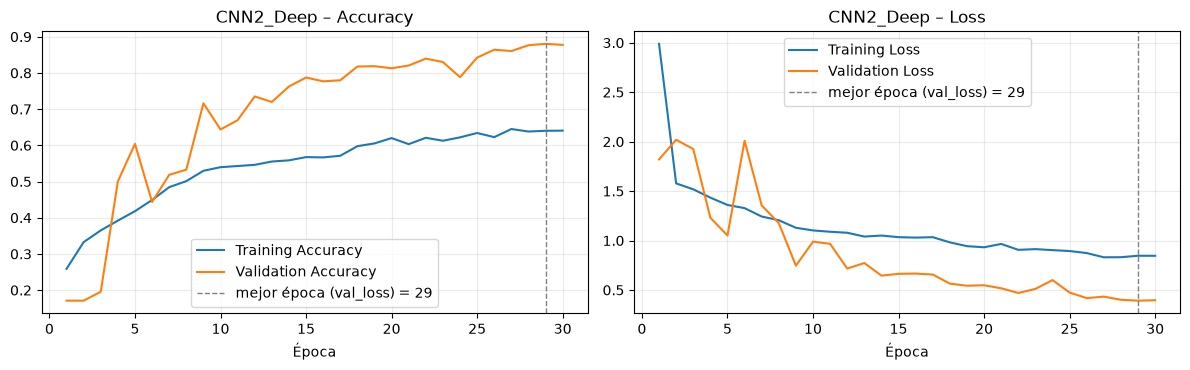

Métricas de CNN2_Deep:


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
train,0.8923,0.8958,0.8924,0.8918
val,0.8803,0.8848,0.8804,0.8803
test,0.8661,0.8718,0.8663,0.8654


classification_report – Test (CNN2_Deep):
              precision    recall  f1-score   support

       Apple     0.8791    0.8939    0.8864       179
      Banana     0.7905    0.9222    0.8513       180
  Bellpepper     0.8776    0.7500    0.8088       172
      Carrot     0.8971    0.9401    0.9181       167
    Cucumber     0.8351    0.9205    0.8757       176
       Mango     0.9517    0.7709    0.8519       179

    accuracy                         0.8661      1053
   macro avg     0.8718    0.8663    0.8654      1053
weighted avg     0.8715    0.8661    0.8651      1053



**CNN2_Deep** entrenó 30 épocas; la mejor (val_loss = 0.3921) fue la **29**. En esa época: Train Acc 0.640 (con augmentation y Dropout activos) vs Val Acc 0.880 (diferencia -0.240); Train Loss 0.846 vs Val Loss 0.392. Diagnóstico: **Validation supera a Train** durante el entrenamiento: es esperable porque Train usa augmentation y Dropout activos; no indica sobreajuste.

**Métricas.** Test: Accuracy **0.8661**, F1 macro **0.8654**. Overfitting Gap (Train−Val, sin augmentation) = **+0.0120**. Clase más difícil en Test: **Bellpepper** (F1 = 0.809); más fácil: **Carrot** (F1 = 0.918).

In [ ]:
evaluar_modelo("CNN2_Deep")

# 17. CNN 3 – Regularized CNN

**Qué se hará:** una arquitectura **distinta** en diseño: kernel inicial **5×5 con stride 2** (reduce resolución desde el inicio y abarca más contexto), 5 convoluciones con filtros 32-64-96-160-256 (**más graduales**), `BatchNormalization` en todas, `Dropout` progresivo (0.2 → 0.3 → 0.4), regularización **L2** (1e-4) en los kernels y, en lugar de `Flatten + Dense` grande, **`GlobalAveragePooling2D`** seguido directamente del clasificador softmax.

**Hipótesis:** una arquitectura **adecuadamente regularizada** puede **generalizar mejor**: GlobalAveragePooling elimina la gran capa densa (menos parámetros y menos memorización), y BatchNorm + Dropout + L2 combaten el sobreajuste.

**Qué esperamos:** muchos menos parámetros que CNN 1 y CNN 2, menor brecha Train–Val y un costo computacional bajo. El riesgo es infraajuste si la regularización es excesiva.

In [ ]:
def build_cnn3():
    reg = regularizers.l2(1e-4)
    def bloque(x, f, k=3, s=1):
        x = layers.Conv2D(f, k, strides=s, padding="same", use_bias=False, kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        return layers.Activation("relu")(x)
    inp = keras.Input((*IMG_SIZE, N_CHANNELS), name="imagen")
    x = bloque(inp, 32, k=5, s=2)                                                  # 64×64
    x = bloque(x, 64);  x = layers.MaxPooling2D()(x); x = layers.Dropout(0.2)(x)   # 32×32
    x = bloque(x, 96);  x = layers.MaxPooling2D()(x); x = layers.Dropout(0.3)(x)   # 16×16
    x = bloque(x, 160); x = layers.MaxPooling2D()(x); x = layers.Dropout(0.3)(x)   # 8×8
    x = bloque(x, 256)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(N_CLASSES, activation="softmax")(x)
    return keras.Model(inp, out, name="CNN3_Regularized")

set_seeds(); _m = compilar(build_cnn3()); _m.summary()
md(f"""**Resultado e interpretación.** CNN 3 tiene **{_m.count_params():,}** parámetros. Al sustituir `Flatten + Dense` por `GlobalAveragePooling2D`, casi todos los parámetros están en las convoluciones. **Implicación:** el modelo es mucho más liviano y rápido de entrenar; su capacidad para memorizar es menor, lo que favorece la generalización si sus características son suficientemente expresivas.""")

Model: "CNN3_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 96)     │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 160)    │       138,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 160)    │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16, 16, 160)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 160)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 256)      │       368,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 586,982 (2.24 MB)

 Trainable params: 585,766 (2.23 MB)

 Non-trainable params: 1,216 (4.75 KB)

**Resultado e interpretación.** CNN 3 tiene **586,982** parámetros. Al sustituir `Flatten + Dense` por `GlobalAveragePooling2D`, casi todos los parámetros están en las convoluciones. **Implicación:** el modelo es mucho más liviano y rápido de entrenar; su capacidad para memorizar es menor, lo que favorece la generalización si sus características son suficientemente expresivas.

# 18. Entrenamiento CNN 3

**Qué se hará:** entrenar CNN 3 con la misma configuración y semilla que las anteriores.

**Qué esperamos:** épocas rápidas (pocas operaciones por imagen) y curvas de Train/Validation cercanas.

In [ ]:
models["CNN3_Regularized"], histories["CNN3_Regularized"] = entrenar("CNN3_Regularized", build_cnn3)

Epoch 1/30


154/154 - 117s - 758ms/step - accuracy: 0.5341 - loss: 1.2769 - val_accuracy: 0.1757 - val_loss: 2.7742 - learning_rate: 0.0010


Epoch 2/30


154/154 - 139s - 904ms/step - accuracy: 0.6656 - loss: 0.9718 - val_accuracy: 0.1909 - val_loss: 4.4446 - learning_rate: 0.0010


Epoch 3/30


...

154/154 - 111s - 722ms/step - accuracy: 0.9247 - loss: 0.2959 - val_accuracy: 0.9088 - val_loss: 0.3547 - learning_rate: 2.5000e-04


Epoch 30/30


154/154 - 111s - 723ms/step - accuracy: 0.9192 - loss: 0.2952 - val_accuracy: 0.9259 - val_loss: 0.3163 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 28.


[CNN3_Regularized] entrenado en 59.3 min, 30 épocas.


# 19. Evaluación CNN 3

**Qué se hará y por qué:** mismo protocolo de evaluación que las anteriores.

**Qué esperamos:** brecha Train–Val pequeña; verificar si la regularización compensa la menor capacidad.

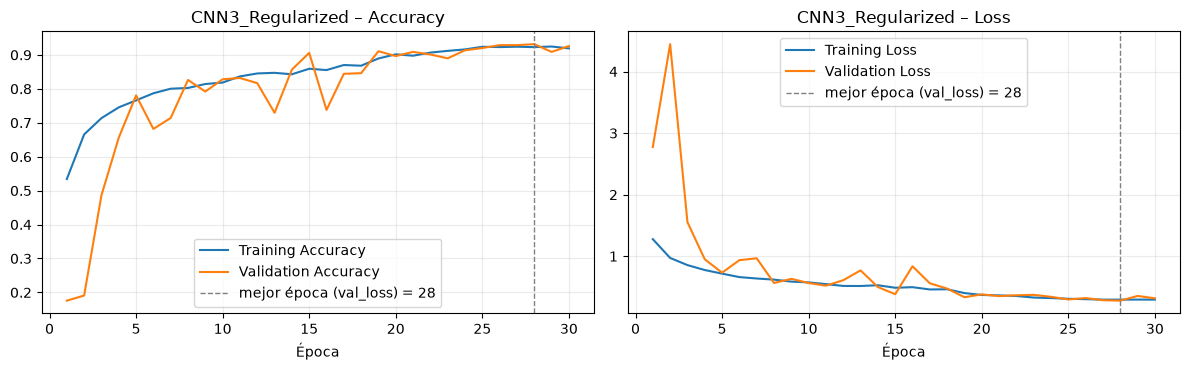

Métricas de CNN3_Regularized:


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
train,0.9516,0.9530,0.9510,0.9504
val,0.9316,0.9328,0.9309,0.9304
test,0.9326,0.9348,0.9319,0.9309


classification_report – Test (CNN3_Regularized):
              precision    recall  f1-score   support

       Apple     0.9494    0.9441    0.9468       179
      Banana     0.9516    0.9833    0.9672       180
  Bellpepper     0.9565    0.7674    0.8516       172
      Carrot     0.9467    0.9581    0.9524       167
    Cucumber     0.8643    0.9773    0.9173       176
       Mango     0.9399    0.9609    0.9503       179

    accuracy                         0.9326      1053
   macro avg     0.9348    0.9319    0.9309      1053
weighted avg     0.9347    0.9326    0.9313      1053



**CNN3_Regularized** entrenó 30 épocas; la mejor (val_loss = 0.2779) fue la **28**. En esa época: Train Acc 0.923 (con augmentation y Dropout activos) vs Val Acc 0.932 (diferencia -0.009); Train Loss 0.295 vs Val Loss 0.278. Diagnóstico: **generalización adecuada**: Train y Validation están cercanos.

**Métricas.** Test: Accuracy **0.9326**, F1 macro **0.9309**. Overfitting Gap (Train−Val, sin augmentation) = **+0.0199**. Clase más difícil en Test: **Bellpepper** (F1 = 0.852); más fácil: **Banana** (F1 = 0.967).

In [ ]:
evaluar_modelo("CNN3_Regularized")

# 20. Comparación de modelos

**Qué se hará:** reunir en una tabla las métricas de las tres CNN (Train/Validation/Test Accuracy, F1 macro, parámetros y *Overfitting Gap*), graficarlas y comparar objetivamente. Se agregan intervalos de confianza de Wilson (95 %) para la accuracy en Test y una prueba de **McNemar** entre los dos mejores modelos.

**Por qué:** una diferencia de 0.5–1 punto porcentual en ~1 000 imágenes de Test puede estar dentro del ruido muestral; los intervalos y la prueba permiten no sobreinterpretar.

**Definiciones.** *Overfitting Gap* = Train Accuracy − Validation Accuracy (Train evaluado **sin** augmentation). Un valor alto indica memorización.

**Qué esperamos:** diferencias moderadas entre modelos, con CNN 3 mucho más liviana en parámetros.

Tabla comparativa:


,Train Accuracy,Validation Accuracy,Test Accuracy,F1 Macro (Val),F1 Macro (Test),Precision Macro (Test),Recall Macro (Test),Parámetros,Overfitting Gap,Épocas,Tiempo (min)
Modelo,,,,,,,,,,,
CNN1_Baseline,0.9764,0.9373,0.9183,0.9371,0.9180,0.9190,0.9181,4288454,0.0391,26,50.1436
CNN2_Deep,0.8923,0.8803,0.8661,0.8803,0.8654,0.8718,0.8663,4771046,0.0120,30,152.7813
CNN3_Regularized,0.9516,0.9316,0.9326,0.9304,0.9309,0.9348,0.9319,586982,0.0199,30,59.2601


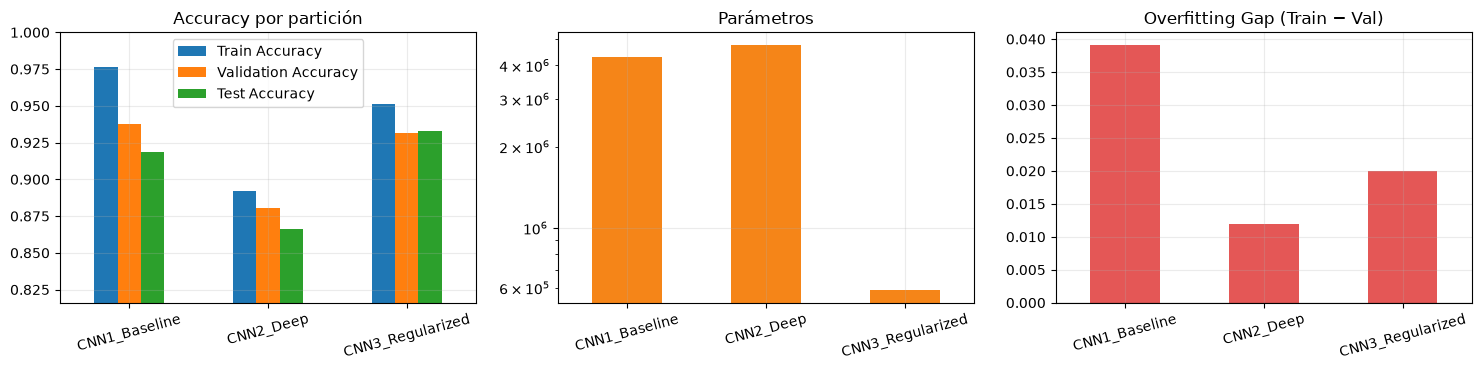

Accuracy en Test con IC 95 % (Wilson):
  CNN1_Baseline      0.9183  [0.9002, 0.9334]
  CNN2_Deep          0.8661  [0.8442, 0.8853]
  CNN3_Regularized   0.9326  [0.9158, 0.9462]
McNemar CNN3_Regularized vs CNN1_Baseline (Test): discordantes 43/28, p = 0.0959


**Resultado.** En Test, el mayor accuracy es de **CNN3_Regularized** (0.9326), seguido de CNN1_Baseline (0.9183) y CNN2_Deep (0.8661). Los parámetros van de 586,982 (**CNN3_Regularized**) a 4,771,046 (**CNN2_Deep**). La menor brecha Train–Val corresponde a **CNN2_Deep** (+0.0120) y la mayor a **CNN1_Baseline** (+0.0391).

**Interpretación.** Los intervalos de confianza de los dos primeros se solapan y McNemar (p = 0.096) no detecta diferencia significativa: **la ventaja de CNN3_Regularized sobre CNN1_Baseline no es concluyente** solo con Test. Un mayor número de parámetros no garantiza mejor rendimiento: conviene relacionar el desempeño con el costo ({'CNN1_Baseline': 50.1, 'CNN2_Deep': 152.8, 'CNN3_Regularized': 59.3} minutos de entrenamiento).

**Implicaciones.** La elección del mejor modelo no se basa en un único número: se aplican los criterios de la sección 24 (Validation, F1 macro, gap, estabilidad, desempeño por clase y tamaño), usando Test solo como confirmación.

In [ ]:
from scipy import stats

def tabla_comparativa():
    filas = []
    for n, r in results.items():
        h = r["history"]
        filas.append({"Modelo": n, "Train Accuracy": r["train"]["acc"], "Validation Accuracy": r["val"]["acc"],
                      "Test Accuracy": r["test"]["acc"], "F1 Macro (Val)": r["val"]["f1"], "F1 Macro (Test)": r["test"]["f1"],
                      "Precision Macro (Test)": r["test"]["prec"], "Recall Macro (Test)": r["test"]["rec"],
                      "Parámetros": r["params"], "Overfitting Gap": r["train"]["acc"] - r["val"]["acc"],
                      "Épocas": len(h["loss"]), "Tiempo (min)": h.get("tiempo_s", np.nan) / 60})
    return pd.DataFrame(filas).set_index("Modelo")

def mcnemar_exacto(pred_a, pred_b, y):
    a_ok, b_ok = pred_a == y, pred_b == y
    b, c = int((a_ok & ~b_ok).sum()), int((~a_ok & b_ok).sum())
    if b + c == 0: return 1.0, b, c
    try: p = stats.binomtest(min(b, c), b + c, 0.5).pvalue
    except AttributeError: p = stats.binom_test(min(b, c), b + c, 0.5)
    return float(p), b, c

comp = tabla_comparativa()
print("Tabla comparativa:"); display(comp.round(4))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
comp[["Train Accuracy", "Validation Accuracy", "Test Accuracy"]].plot(kind="bar", ax=ax[0], rot=15)
ax[0].set_ylim(max(0, comp[["Train Accuracy", "Validation Accuracy", "Test Accuracy"]].values.min() - 0.05), 1.0); ax[0].set_title("Accuracy por partición")
comp["Parámetros"].plot(kind="bar", ax=ax[1], color="#F58518", rot=15); ax[1].set_title("Parámetros"); ax[1].set_yscale("log")
comp["Overfitting Gap"].plot(kind="bar", ax=ax[2], color="#E45756", rot=15); ax[2].set_title("Overfitting Gap (Train − Val)"); ax[2].axhline(0, color="k", lw=0.8)
for a in ax: a.set_xlabel("")
plt.tight_layout(); savefig("20_comparacion"); plt.show()

n_test = len(idx_test)
ic = {n: wilson_ci(int(round(r["test"]["acc"] * n_test)), n_test) for n, r in results.items()}
print("Accuracy en Test con IC 95 % (Wilson):")
for n, (lo, hi) in ic.items(): print(f"  {n:18s} {comp.loc[n,'Test Accuracy']:.4f}  [{lo:.4f}, {hi:.4f}]")

orden = comp["Test Accuracy"].sort_values(ascending=False).index.tolist()
p_mc, b_, c_ = mcnemar_exacto(results[orden[0]]["test"]["pred"], results[orden[1]]["test"]["pred"], results[orden[0]]["test"]["y"])
print(f"McNemar {orden[0]} vs {orden[1]} (Test): discordantes {b_}/{c_}, p = {p_mc:.4f}")

g = comp["Overfitting Gap"]
md(f"""**Resultado.** En Test, el mayor accuracy es de **{orden[0]}** ({comp.loc[orden[0],'Test Accuracy']:.4f}), seguido de {orden[1]} ({comp.loc[orden[1],'Test Accuracy']:.4f}) y {orden[2]} ({comp.loc[orden[2],'Test Accuracy']:.4f}). Los parámetros van de {int(comp['Parámetros'].min()):,} (**{comp['Parámetros'].idxmin()}**) a {int(comp['Parámetros'].max()):,} (**{comp['Parámetros'].idxmax()}**). La menor brecha Train–Val corresponde a **{g.idxmin()}** ({g.min():+.4f}) y la mayor a **{g.idxmax()}** ({g.max():+.4f}).

**Interpretación.** {'Los intervalos de confianza de los dos primeros se solapan y McNemar (p = %.3f) no detecta diferencia significativa: **la ventaja de %s sobre %s no es concluyente** solo con Test.' % (p_mc, orden[0], orden[1]) if p_mc >= 0.05 else 'McNemar (p = %.3f) indica que la diferencia entre %s y %s en Test es **estadísticamente significativa**.' % (p_mc, orden[0], orden[1])} Un mayor número de parámetros no garantiza mejor rendimiento: conviene relacionar el desempeño con el costo ({comp['Tiempo (min)'].round(1).to_dict()} minutos de entrenamiento).

**Implicaciones.** La elección del mejor modelo no se basa en un único número: se aplican los criterios de la sección 24 (Validation, F1 macro, gap, estabilidad, desempeño por clase y tamaño), usando Test solo como confirmación.""")

# 21. Matriz de confusión

**Qué se hará:** seleccionar el mejor modelo con la función de ranking (justificada formalmente en la sección 24) y construir su matriz de confusión en **Test**, en conteos y normalizada por fila (recall por clase).

**Por qué:** la matriz muestra *qué* clases se confunden, información que el accuracy global oculta.

**Qué esperamos:** diagonal dominante y confusiones concentradas en los pares visualmente parecidos identificados en la sección 06.

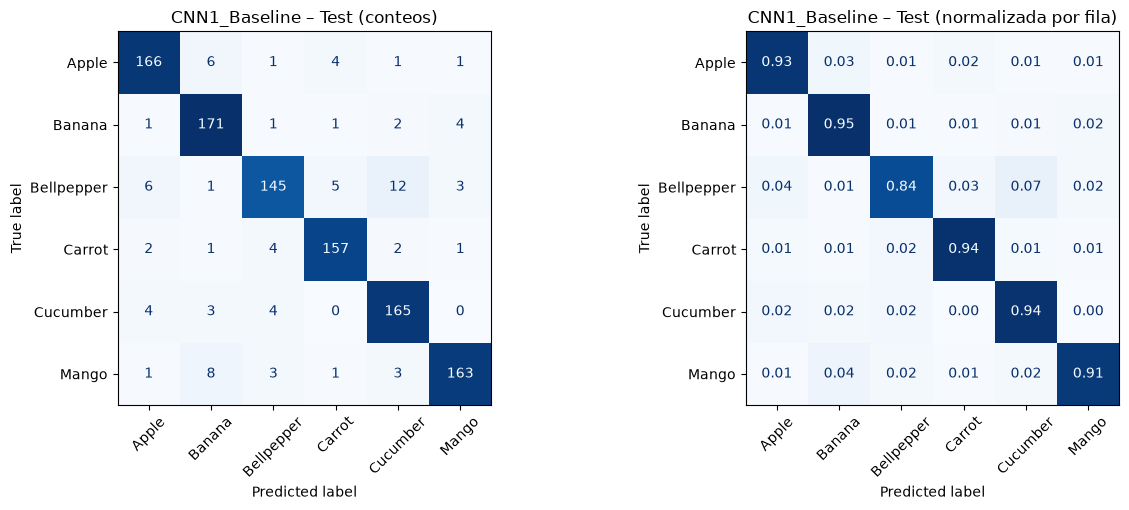

Errores en Test: 86 de 1053 (8.17%)

Pares más confundidos (real → predicho):


n
real       pred          
Bellpepper Cucumber    12
Mango      Banana       8
Apple      Banana       6
Bellpepper Apple        6
           Carrot       5
Carrot     Bellpepper   4

Tasa de error por clase:


,error
Bellpepper,0.157
Mango,0.089
Apple,0.073
Cucumber,0.062
Carrot,0.060
Banana,0.050


**Resultado.** El modelo seleccionado, **CNN1_Baseline**, comete **86** errores en 1053 imágenes de Test. La clase con mayor tasa de error es **Bellpepper** (15.7%) y la menor **Banana** (5.0%). Del total de errores, 48 (56%) ocurren **dentro de la misma categoría** (fruta↔fruta o vegetal↔vegetal).

**Confusiones principales:**
- **Bellpepper → Cucumber**: 12 errores, de los cuales 7 son imágenes *Rotten* (58%); misma categoría (Vegetal).
- **Mango → Banana**: 8 errores, de los cuales 2 son imágenes *Rotten* (25%); misma categoría (Fruta).
- **Apple → Banana**: 6 errores, de los cuales 6 son imágenes *Rotten* (100%); misma categoría (Fruta).

**Posibles causas** (a contrastar visualmente en la sección 22): productos podridos que pierden color y forma característicos y se parecen entre sí; formas o colores compartidos (redondeados/rojizos o amarillos/verdes); fondos o encuadres poco informativos; y resolución baja (128×128) que borra detalle de textura. **Implicación:** las mejoras más prometedoras son más resolución/transfer learning y augmentation dirigida a las clases confundidas.

In [ ]:
PESOS = {"F1 macro (Val)": 0.35, "F1 mínimo por clase (Val)": 0.20, "Overfitting Gap": 0.20, "Estabilidad": 0.10, "Parámetros": 0.15}

def seleccionar_mejor():
    filas = {}
    for n, r in results.items():
        h = r["history"]
        filas[n] = {"F1 macro (Val)": r["val"]["f1"], "F1 mínimo por clase (Val)": r["val"]["f1_clase"].min(),
                    "Overfitting Gap": max(0.0, r["train"]["acc"] - r["val"]["acc"]),
                    "Estabilidad": float(np.std(h["val_accuracy"][-5:])), "Parámetros": r["params"]}
    d = pd.DataFrame(filas).T
    # Empates: diferencias < 1 pp (F1, gap), < 0.005 (estabilidad) y < 0.1 en log10 (parámetros) se tratan como empate
    r_ = pd.DataFrame({
        "F1 macro (Val)": (-d["F1 macro (Val)"]).round(2).rank(method="min"),
        "F1 mínimo por clase (Val)": (-d["F1 mínimo por clase (Val)"]).round(2).rank(method="min"),
        "Overfitting Gap": d["Overfitting Gap"].round(2).rank(method="min"),
        "Estabilidad": d["Estabilidad"].round(3).rank(method="min"),
        "Parámetros": np.log10(d["Parámetros"]).round(1).rank(method="min")})
    d["Puntaje ponderado (menor = mejor)"] = sum(r_[k] * w for k, w in PESOS.items())
    d = d.sort_values(["Puntaje ponderado (menor = mejor)", "F1 macro (Val)"], ascending=[True, False])
    return d.index[0], d, r_

BEST, ranking, rangos = seleccionar_mejor()
rb = results[BEST]; y_t, p_t = rb["test"]["y"], rb["test"]["pred"]
cm = confusion_matrix(y_t, p_t, labels=range(N_CLASSES))
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax[0], cmap="Blues", colorbar=False, xticks_rotation=45)
ConfusionMatrixDisplay(np.round(cmn, 3), display_labels=CLASSES).plot(ax=ax[1], cmap="Blues", colorbar=False, xticks_rotation=45, values_format=".2f")
ax[0].set_title(f"{BEST} – Test (conteos)"); ax[1].set_title(f"{BEST} – Test (normalizada por fila)")
for a in ax: a.grid(False)
plt.tight_layout(); savefig("21_matriz_confusion"); plt.show()

# Análisis de errores
test_meta = df_u.loc[idx_test, ["clase", "condicion", "ruta"]].reset_index(drop=True)
mal = p_t != y_t
ERR = test_meta[mal].copy(); ERR["real"] = [CLASSES[i] for i in y_t[mal]]; ERR["pred"] = [CLASSES[i] for i in p_t[mal]]
pares_err = ERR.groupby(["real", "pred"]).size().sort_values(ascending=False)
TOP_CONF = pares_err.head(3)
n_err = int(mal.sum())
dentro = int(sum(1 for r_, p_ in zip(ERR.real, ERR.pred) if GRUPO[r_] == GRUPO[p_]))
tasa_err = pd.Series(1 - np.diag(cm) / cm.sum(axis=1), index=CLASSES).sort_values(ascending=False)
print(f"Errores en Test: {n_err} de {len(y_t)} ({n_err/len(y_t):.2%})"); print("\nPares más confundidos (real → predicho):"); display(pares_err.head(6).to_frame("n"))
print("Tasa de error por clase:"); display(tasa_err.round(3).to_frame("error"))

if n_err > 0:
    lineas = []
    for (rr, pp), k in TOP_CONF.items():
        sub = ERR[(ERR.real == rr) & (ERR.pred == pp)]
        n_rot = int((sub.condicion == "Rotten").sum())
        rel = "misma categoría (" + GRUPO[rr] + ")" if GRUPO[rr] == GRUPO[pp] else f"categorías distintas ({GRUPO[rr]}/{GRUPO[pp]})"
        lineas.append(f"- **{rr} → {pp}**: {k} errores, de los cuales {n_rot} son imágenes *Rotten* ({n_rot/k:.0%}); {rel}.")
    texto_err = "\n".join(lineas)
    md(f"""**Resultado.** El modelo seleccionado, **{BEST}**, comete **{n_err}** errores en {len(y_t)} imágenes de Test. La clase con mayor tasa de error es **{tasa_err.index[0]}** ({tasa_err.iloc[0]:.1%}) y la menor **{tasa_err.index[-1]}** ({tasa_err.iloc[-1]:.1%}). Del total de errores, {dentro} ({dentro/n_err:.0%}) ocurren **dentro de la misma categoría** (fruta↔fruta o vegetal↔vegetal).

**Confusiones principales:**
{texto_err}

**Posibles causas** (a contrastar visualmente en la sección 22): productos podridos que pierden color y forma característicos y se parecen entre sí; formas o colores compartidos (redondeados/rojizos o amarillos/verdes); fondos o encuadres poco informativos; y resolución baja (128×128) que borra detalle de textura. **Implicación:** las mejoras más prometedoras son más resolución/transfer learning y augmentation dirigida a las clases confundidas.""")
else:
    md("**Resultado.** El modelo no cometió errores en Test; se recomienda validar con más datos externos antes de concluir generalización perfecta.")

# 22. Predicciones

**Qué se hará:** mostrar imágenes del conjunto **Test** con su clase real, la predicción y la **probabilidad** asignada; se incluyen aciertos aleatorios y los errores en que el modelo estaba **más seguro**.

**Por qué:** ver los errores concretos permite juzgar si son razonables (imagen ambigua, producto muy deteriorado) o revelan un problema sistemático.

**Qué esperamos:** aciertos con probabilidades altas; errores con probabilidades más bajas y, en su mayoría, en imágenes difíciles.

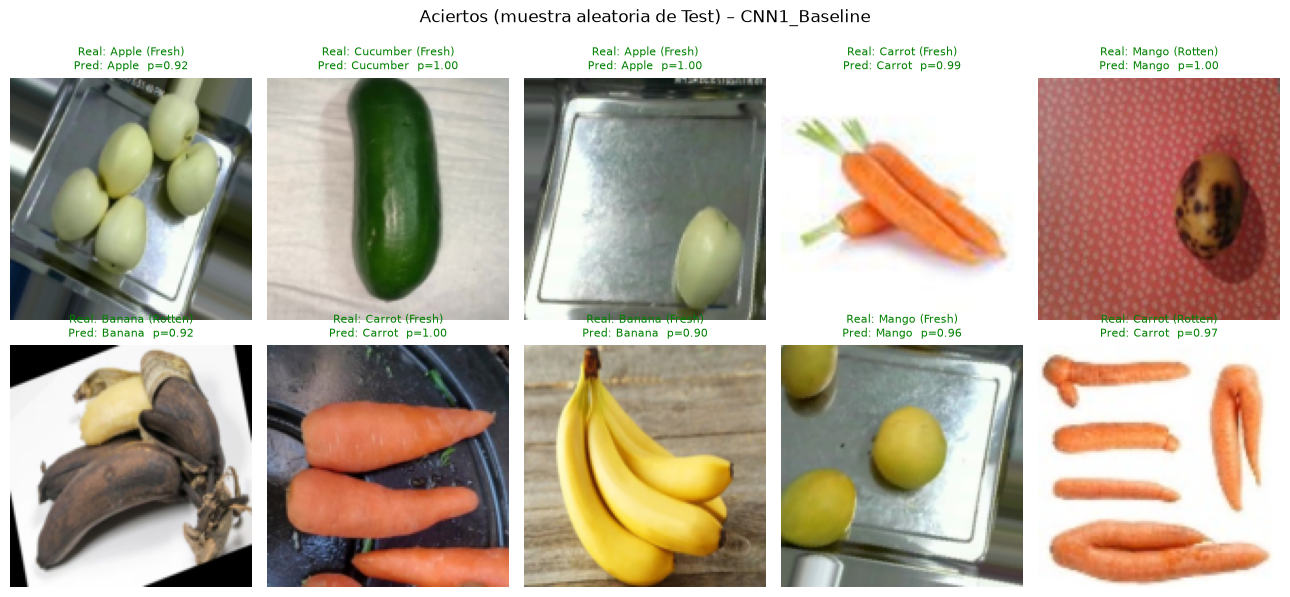

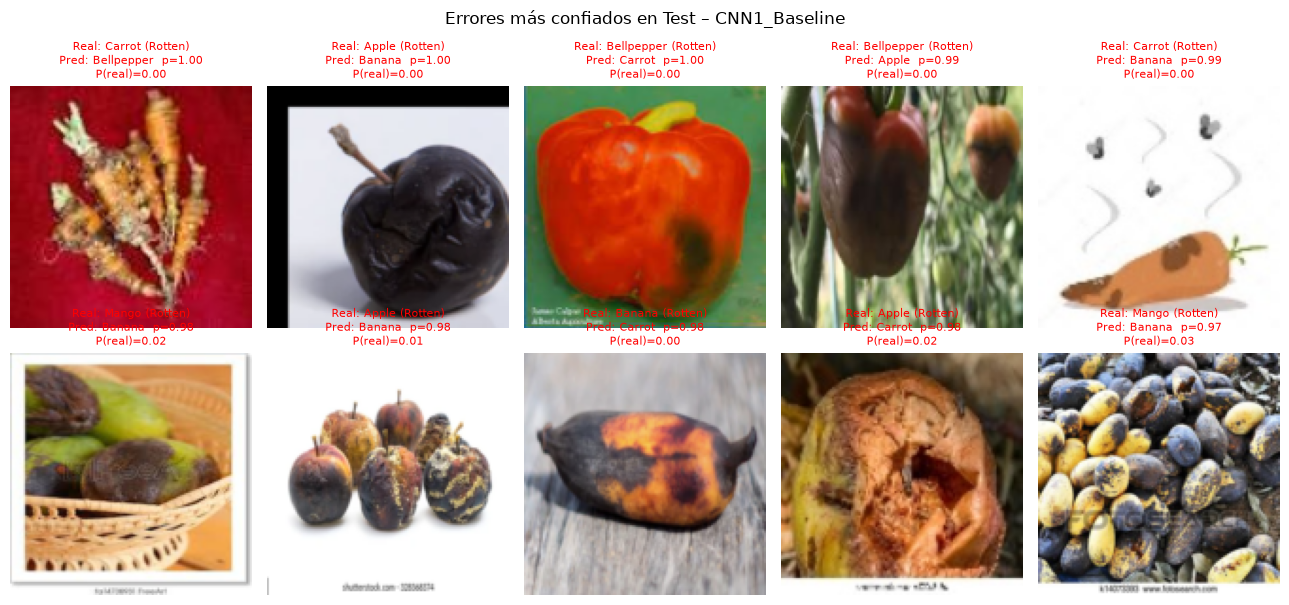

**Resultado e interpretación.** Los aciertos muestran probabilidades típicas de **1.00** (mediana), mientras que en los errores la mediana es **0.76**: el modelo tiende a estar menos seguro cuando se equivoca, lo que permitiría usar un umbral de confianza para derivar casos dudosos a revisión humana. **Implicación:** revise la figura de errores para comprobar si corresponden a imágenes ambiguas o a los pares confundidos de la sección 21.

In [ ]:
def mostrar_predicciones(pos, titulo, ncols=5):
    pos = list(pos)
    if not pos: print("(sin ejemplos)"); return
    filas = int(np.ceil(len(pos) / ncols))
    fig, axes = plt.subplots(filas, ncols, figsize=(2.6 * ncols, 3.0 * filas)); axes = np.atleast_1d(axes).ravel()
    for a in axes: a.axis("off")
    for a, k in zip(axes, pos):
        real, pred = int(y_t[k]), int(p_t[k]); pr = rb["test"]["probs"][k]
        a.imshow(np.asarray(X[idx_test[k]]))
        ok = real == pred
        txt = f"Real: {CLASSES[real]} ({df_u.condicion[idx_test[k]]})\nPred: {CLASSES[pred]}  p={pr[pred]:.2f}"
        if not ok: txt += f"\nP(real)={pr[real]:.2f}"
        a.set_title(txt, fontsize=8, color=("green" if ok else "red"))
    fig.suptitle(f"{titulo} – {BEST}", y=1.0); plt.tight_layout(); savefig("22_" + titulo.split()[0].lower()); plt.show()

rng = np.random.default_rng(SEED)
aciertos = np.where(~mal)[0]
mostrar_predicciones(rng.choice(aciertos, size=min(10, len(aciertos)), replace=False), "Aciertos (muestra aleatoria de Test)")
conf_max = rb["test"]["probs"].max(axis=1)
errores = np.where(mal)[0]
mostrar_predicciones(errores[np.argsort(-conf_max[errores])][:10], "Errores más confiados en Test")

if n_err > 0:
    md(f"""**Resultado e interpretación.** Los aciertos muestran probabilidades típicas de **{np.median(conf_max[~mal]):.2f}** (mediana), mientras que en los errores la mediana es **{np.median(conf_max[mal]):.2f}**: {'el modelo tiende a estar menos seguro cuando se equivoca, lo que permitiría usar un umbral de confianza para derivar casos dudosos a revisión humana.' if np.median(conf_max[mal]) < np.median(conf_max[~mal]) - 0.05 else 'el modelo se equivoca con seguridad similar a la de sus aciertos, por lo que la probabilidad no es un buen indicador de error en este caso.'} **Implicación:** revise la figura de errores para comprobar si corresponden a imágenes ambiguas o a los pares confundidos de la sección 21.""")

# 23. Análisis Fresh vs Rotten

**Qué se hará:** usando el metadato `condicion` (que **no** es una clase), calcular la accuracy del modelo seleccionado en imágenes *Fresh* y en imágenes *Rotten* de Test, por condición y por clase, y contrastar si la diferencia es estadísticamente distinguible.

**Por qué:** un producto podrido cambia de color, textura y forma; puede ser más difícil de reconocer *como producto*. Este análisis es **complementario** y no sustituye la clasificación de las 6 clases.

**Qué esperamos:** accuracy algo menor en Rotten, con mayor dificultad en productos cuyo deterioro produce tonos oscuros similares entre clases. Por clase, cada celda (clase × condición) tiene pocas imágenes en Test (~90), así que los intervalos serán amplios.

Accuracy por condición – CNN1_Baseline (Test):


,Accuracy,Aciertos,n Test,IC95% inf,IC95% sup
Condición,,,,,
Fresh,0.9596,522,544,0.9395,0.9731
Rotten,0.8743,445,509,0.8426,0.9003


Accuracy por condición – todos los modelos (Test):


,CNN1_Baseline,CNN2_Deep,CNN3_Regularized
Fresh,0.9596,0.9173,0.9706
Rotten,0.8743,0.8114,0.8919


Accuracy por clase y condición (Test):


condicion,Fresh,Rotten,Δ (Rotten − Fresh)
clase,,,
Apple,1.000,0.852,-0.148
Banana,0.925,0.977,0.052
Bellpepper,0.944,0.732,-0.213
Carrot,0.989,0.882,-0.107
Cucumber,0.966,0.908,-0.058
Mango,0.933,0.888,-0.046


n por celda:


condicion,Fresh,Rotten
clase,,
Apple,91,88
Banana,93,87
Bellpepper,90,82
Carrot,91,76
Cucumber,89,87
Mango,90,89


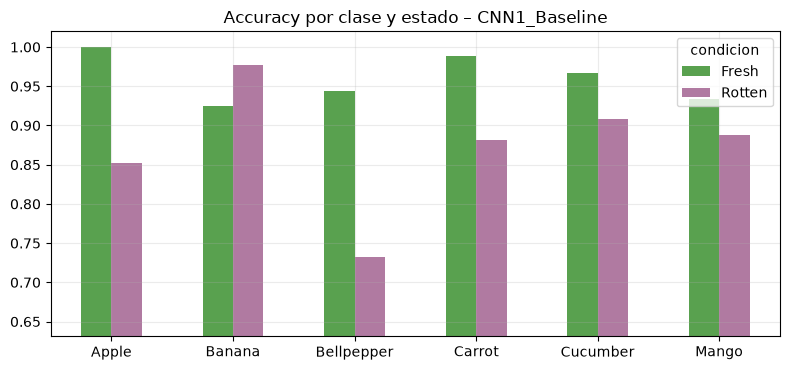

**Resultado.** Accuracy en **Fresh = 0.9596** (n = 544) y en **Rotten = 0.8743** (n = 509); diferencia Fresh − Rotten = **+0.0853** (prueba exacta de Fisher: p = 0.000).

**Interpretación.** El estado del producto **sí parece afectar** el desempeño: las imágenes Rotten se clasifican peor. La celda más difícil es **Bellpepper · Rotten** (accuracy 0.732, n = 82), y la mayor caída al pasar de Fresh a Rotten se da en **Bellpepper** (Δ = -0.213). Con ~76–93 imágenes por celda, las diferencias por clase son **indicativas, no concluyentes**.

**Implicaciones.** Este análisis es complementario: la tarea sigue siendo clasificar el producto en 6 clases. Si Rotten resulta más difícil, conviene más datos de productos deteriorados o augmentation de color/brillo dirigida.

In [ ]:
from scipy.stats import fisher_exact

ok_b = (p_t == y_t)
test_cond = test_meta["condicion"].values; test_clase = test_meta["clase"].values

def acc_condicion(r):
    ok = (r["test"]["pred"] == r["test"]["y"])
    return {c: (ok[test_cond == c].mean(), int(ok[test_cond == c].sum()), int((test_cond == c).sum())) for c in ["Fresh", "Rotten"]}

tab_c = pd.DataFrame({"Condición": ["Fresh", "Rotten"]})
ac = acc_condicion(rb)
tab_c["Accuracy"] = [ac[c][0] for c in ["Fresh", "Rotten"]]
tab_c["Aciertos"] = [ac[c][1] for c in ["Fresh", "Rotten"]]
tab_c["n Test"] = [ac[c][2] for c in ["Fresh", "Rotten"]]
tab_c["IC95% inf"] = [wilson_ci(ac[c][1], ac[c][2])[0] for c in ["Fresh", "Rotten"]]
tab_c["IC95% sup"] = [wilson_ci(ac[c][1], ac[c][2])[1] for c in ["Fresh", "Rotten"]]
print(f"Accuracy por condición – {BEST} (Test):"); display(tab_c.set_index("Condición").round(4))

print("Accuracy por condición – todos los modelos (Test):")
display(pd.DataFrame({n: {c: acc_condicion(r)[c][0] for c in ["Fresh", "Rotten"]} for n, r in results.items()}).round(4))

pc = pd.DataFrame({"clase": test_clase, "condicion": test_cond, "ok": ok_b})
acc_cc = pc.pivot_table(index="clase", columns="condicion", values="ok", aggfunc="mean").reindex(CLASSES)
n_cc = pc.pivot_table(index="clase", columns="condicion", values="ok", aggfunc="count").reindex(CLASSES)
acc_cc["Δ (Rotten − Fresh)"] = acc_cc["Rotten"] - acc_cc["Fresh"]
print("Accuracy por clase y condición (Test):"); display(acc_cc.round(3)); print("n por celda:"); display(n_cc)

fig, ax = plt.subplots(figsize=(8, 3.8))
acc_cc[["Fresh", "Rotten"]].plot(kind="bar", ax=ax, color=["#59A14F", "#B07AA1"], rot=0)
ax.set_ylim(max(0, acc_cc[["Fresh", "Rotten"]].values.min() - 0.1), 1.02); ax.set_title(f"Accuracy por clase y estado – {BEST}"); ax.set_xlabel("")
plt.tight_layout(); savefig("23_fresh_vs_rotten"); plt.show()

tabla_f = [[ac["Fresh"][1], ac["Fresh"][2] - ac["Fresh"][1]], [ac["Rotten"][1], ac["Rotten"][2] - ac["Rotten"][1]]]
p_fr = fisher_exact(tabla_f)[1]
dif = ac["Fresh"][0] - ac["Rotten"][0]
peor = acc_cc[["Fresh", "Rotten"]].stack().sort_values().head(1)
(peor_clase, peor_cond), peor_acc = peor.index[0], float(peor.iloc[0])
mayor_caida = acc_cc["Δ (Rotten − Fresh)"].idxmin()
md(f"""**Resultado.** Accuracy en **Fresh = {ac['Fresh'][0]:.4f}** (n = {ac['Fresh'][2]}) y en **Rotten = {ac['Rotten'][0]:.4f}** (n = {ac['Rotten'][2]}); diferencia Fresh − Rotten = **{dif:+.4f}** (prueba exacta de Fisher: p = {p_fr:.3f}).

**Interpretación.** {'El estado del producto **sí parece afectar** el desempeño: las imágenes Rotten se clasifican peor.' if (dif > 0 and p_fr < 0.05) else ('Hay una diferencia a favor de Fresh, pero **no es estadísticamente concluyente** con este tamaño de Test.' if dif > 0 else 'No se observa que Rotten sea más difícil que Fresh; incluso rinde igual o mejor.')} La celda más difícil es **{peor_clase} · {peor_cond}** (accuracy {peor_acc:.3f}, n = {int(n_cc.loc[peor_clase, peor_cond])}), y la mayor caída al pasar de Fresh a Rotten se da en **{mayor_caida}** (Δ = {acc_cc.loc[mayor_caida,'Δ (Rotten − Fresh)']:+.3f}). Con ~{int(n_cc.values.min())}–{int(n_cc.values.max())} imágenes por celda, las diferencias por clase son **indicativas, no concluyentes**.

**Implicaciones.** Este análisis es complementario: la tarea sigue siendo clasificar el producto en 6 clases. Si Rotten resulta más difícil, conviene más datos de productos deteriorados o augmentation de color/brillo dirigida.""")

# 24. Selección del mejor modelo

**Qué se hará:** aplicar un **ranking multicriterio transparente** que **no** se decide por Training Accuracy y que **no usa Test** para elegir: Validation (F1 macro), peor clase (F1 mínimo), *Overfitting Gap*, estabilidad (desviación estándar de la Validation Accuracy en las últimas 5 épocas) y número de parámetros. **Test se usa solo como confirmación** (una decisión basada en Test lo convertiría en parte del proceso de selección).

**Regla:** cada criterio se convierte en un ranking (1 = mejor; diferencias menores a 1 pp se tratan como empate), se pondera y gana el menor puntaje; el desempate es el F1 macro de Validation.

In [ ]:
print("Pesos de los criterios:", PESOS)
print("\nValores de cada criterio (entre paréntesis en el ranking, 1 = mejor):")
display(ranking.round(4))
print("Posiciones por criterio:"); display(rangos.loc[ranking.index])

f1c = pd.DataFrame({n: results[n]["val"]["f1_clase"] for n in results}, index=CLASSES).round(3)
print("F1 por clase en Validation (desempeño por clase):"); display(f1c)

arq = {}
def describir_arquitectura(model):
    Ls = model.layers
    return dict(n_conv=sum(isinstance(l, layers.Conv2D) for l in Ls),
                bn=any(isinstance(l, layers.BatchNormalization) for l in Ls),
                gap=any(isinstance(l, layers.GlobalAveragePooling2D) for l in Ls),
                dropout=[float(l.rate) for l in Ls if isinstance(l, layers.Dropout)],
                l2=any(getattr(l, "kernel_regularizer", None) is not None for l in Ls if isinstance(l, layers.Conv2D)),
                params=model.count_params())
for n, m in models.items(): arq[n] = describir_arquitectura(m)

seg = [n for n in ranking.index if n != BEST][0]
conf_test = "coincide" if results[BEST]["test"]["acc"] >= max(r["test"]["acc"] for r in results.values()) - 1e-12 else "no coincide"
mejor_test = max(results, key=lambda n: results[n]["test"]["acc"])
md(f"""**Modelo seleccionado: {BEST}.**

- **Validation:** Accuracy {results[BEST]['val']['acc']:.4f}, F1 macro {results[BEST]['val']['f1']:.4f}, F1 de su peor clase {results[BEST]['val']['f1_clase'].min():.3f} ({CLASSES[int(np.argmin(results[BEST]['val']['f1_clase']))]}).
- **Generalización:** Overfitting Gap {results[BEST]['train']['acc']-results[BEST]['val']['acc']:+.4f}; estabilidad (σ de val_accuracy, últimas 5 épocas) {ranking.loc[BEST,'Estabilidad']:.4f}.
- **Tamaño:** {results[BEST]['params']:,} parámetros ({arq[BEST]['n_conv']} capas convolucionales).
- **Frente al segundo ({seg}):** F1 macro Val {results[seg]['val']['f1']:.4f} vs {results[BEST]['val']['f1']:.4f}; gap {results[seg]['train']['acc']-results[seg]['val']['acc']:+.4f} vs {results[BEST]['train']['acc']-results[BEST]['val']['acc']:+.4f}; parámetros {results[seg]['params']:,} vs {results[BEST]['params']:,}.
- **Confirmación en Test (no usada para decidir):** Accuracy {results[BEST]['test']['acc']:.4f} y F1 macro {results[BEST]['test']['f1']:.4f}. La selección por Validation **{conf_test}** con el modelo de mayor accuracy en Test (**{mejor_test}**){'.' if conf_test == 'coincide' else '; la diferencia debe interpretarse con los intervalos y la prueba de McNemar de la sección 20 antes de considerarla relevante.'}

**Por qué no se elige por Training Accuracy:** mide memorización, no generalización; un modelo con Train Accuracy máxima puede ser el que más sobreajusta. Por eso el criterio dominante es el rendimiento en datos no vistos durante el ajuste (Validation), junto con la brecha, la estabilidad y el rendimiento en la peor clase.""")

Pesos de los criterios: {'F1 macro (Val)': 0.35, 'F1 mínimo por clase (Val)': 0.2, 'Overfitting Gap': 0.2, 'Estabilidad': 0.1, 'Parámetros': 0.15}

Valores de cada criterio (entre paréntesis en el ranking, 1 = mejor):


,F1 macro (Val),F1 mínimo por clase (Val),Overfitting Gap,Estabilidad,Parámetros,Puntaje ponderado (menor = mejor)
CNN1_Baseline,0.9371,0.8818,0.0391,0.0037,4288454.0,1.55
CNN3_Regularized,0.9304,0.8553,0.0199,0.0082,586982.0,1.85
CNN2_Deep,0.8803,0.8218,0.0120,0.0079,4771046.0,2.50


Posiciones por criterio:


,F1 macro (Val),F1 mínimo por clase (Val),Overfitting Gap,Estabilidad,Parámetros
CNN1_Baseline,1.0,1.0,3.0,1.0,2.0
CNN3_Regularized,2.0,2.0,2.0,2.0,1.0
CNN2_Deep,3.0,3.0,1.0,2.0,3.0


F1 por clase en Validation (desempeño por clase):


,CNN1_Baseline,CNN2_Deep,CNN3_Regularized
Apple,0.955,0.924,0.964
Banana,0.956,0.865,0.970
Bellpepper,0.882,0.822,0.855
Carrot,0.940,0.927,0.943
Cucumber,0.949,0.879,0.916
Mango,0.941,0.865,0.934


**Modelo seleccionado: CNN1_Baseline.**

- **Validation:** Accuracy 0.9373, F1 macro 0.9371, F1 de su peor clase 0.882 (Bellpepper).
- **Generalización:** Overfitting Gap +0.0391; estabilidad (σ de val_accuracy, últimas 5 épocas) 0.0037.
- **Tamaño:** 4,288,454 parámetros (3 capas convolucionales).
- **Frente al segundo (CNN3_Regularized):** F1 macro Val 0.9304 vs 0.9371; gap +0.0199 vs +0.0391; parámetros 586,982 vs 4,288,454.
- **Confirmación en Test (no usada para decidir):** Accuracy 0.9183 y F1 macro 0.9180. La selección por Validation **no coincide** con el modelo de mayor accuracy en Test (**CNN3_Regularized**); la diferencia debe interpretarse con los intervalos y la prueba de McNemar de la sección 20 antes de considerarla relevante.

**Por qué no se elige por Training Accuracy:** mide memorización, no generalización; un modelo con Train Accuracy máxima puede ser el que más sobreajusta. Por eso el criterio dominante es el rendimiento en datos no vistos durante el ajuste (Validation), junto con la brecha, la estabilidad y el rendimiento en la peor clase.

# 25. Respuesta a la pregunta central

### ¿Por qué cree que la CNN seleccionada funciona mejor que las otras?

**Qué se hará:** relacionar los resultados reales con arquitectura, profundidad, extracción de características, regularización (BatchNormalization, Dropout, L2), Data Augmentation, generalización y métricas. Cada afirmación se apoya en números calculados en este notebook.

**Advertencia metodológica:** los tres modelos difieren en varios factores a la vez (profundidad, tipo de capa final, BatchNorm, regularización), de modo que los resultados **sugieren** explicaciones pero no aíslan efectos individuales sin experimentos de ablación.

In [ ]:
B = BEST; others = [n for n in results if n != B]
a = arq[B]; rB = results[B]
prof = {n: arq[n]["n_conv"] for n in results}; par = {n: arq[n]["params"] for n in results}
mas_profunda = max(prof, key=prof.get); mas_param = max(par, key=par.get)
ep_mejor = {n: int(np.argmin(results[n]["history"]["val_loss"])) + 1 for n in results}
gap = {n: results[n]["train"]["acc"] - results[n]["val"]["acc"] for n in results}

resumen = "; ".join(f"{n}: Val F1 {results[n]['val']['f1']:.3f}, Test Acc {results[n]['test']['acc']:.3f}" for n in results)
p1 = f"**Resultado.** {B} obtuvo Validation Accuracy {rB['val']['acc']:.3f} / F1 macro {rB['val']['f1']:.3f} y Test Accuracy {rB['test']['acc']:.3f} / F1 macro {rB['test']['f1']:.3f}. Comparativa: {resumen}."

if B == mas_profunda and len(set(prof.values())) > 1:
    p2 = (f"**Arquitectura y profundidad.** {B} es la más profunda ({prof[B]} capas convolucionales; " + ", ".join(f"{n}: {prof[n]}" for n in others) +
          f") y la de mejor ranking, coherente con la hipótesis de que más capas extraen rasgos más complejos (texturas de descomposición, formas compuestas) que los bordes y formas simples de la red baseline.")
else:
    p2 = (f"**Arquitectura y profundidad.** {B} tiene {prof[B]} capas convolucionales; la más profunda es {mas_profunda} ({prof[mas_profunda]}) y **no** es la mejor. En este dataset, más profundidad no se tradujo por sí sola en mejor generalización: pesa más cómo se organizan y regularizan las capas.")

if a["gap"]:
    p3 = (f"**Extracción de características.** {B} termina en `GlobalAveragePooling2D`, que resume cada mapa de características en un valor y exige que cada canal codifique evidencia de clase. Esto reduce los parámetros a {par[B]:,} (frente a {par[mas_param]:,} de {mas_param}) y elimina la gran capa densa donde suele producirse la memorización.")
else:
    p3 = (f"**Extracción de características.** {B} usa `Flatten + Dense`, que conserva la información espacial de los mapas de características, a costa de {par[B]:,} parámetros; esa capacidad extra permite representar detalles finos pero exige más regularización.")

con_bn = [n for n in results if arq[n]["bn"]]; sin_bn = [n for n in results if not arq[n]["bn"]]
p4 = (f"**BatchNormalization.** {'Incluida' if a['bn'] else 'No incluida'} en {B}. Épocas hasta la mejor val_loss: " + ", ".join(f"{n} = {ep_mejor[n]}" for n in results) +
      (f". Con BatchNorm ({', '.join(con_bn) or 'ninguno'}) frente a sin ({', '.join(sin_bn) or 'ninguno'}) la optimización se comporta de forma distinta; la estabilidad de val_accuracy (σ, últimas 5 épocas) es " + ", ".join(f"{n}: {ranking.loc[n,'Estabilidad']:.4f}" for n in results) + "." ))

p5 = (f"**Dropout y regularización.** Tasas de Dropout de {B}: {a['dropout']}{' y L2 en los kernels' if a['l2'] else ''}. Overfitting Gap (Train−Val): " + ", ".join(f"{n} = {gap[n]:+.3f}" for n in results) +
      f". {'La brecha de ' + B + ' es la menor o está entre las menores, consistente con una mejor regularización.' if gap[B] <= min(gap.values()) + 0.005 else 'La brecha de ' + B + ' no es la menor; su ventaja proviene más de su capacidad de representación que de una menor memorización.'}")

p6 = ("**Data Augmentation.** Fue idéntica para las tres redes, por lo que **no explica las diferencias entre ellas**; sí contribuye a que las brechas Train–Val sean contenidas en todas. Para medir su aporte real haría falta un experimento sin augmentation (trabajo futuro).")

pm, b_, c_ = mcnemar_exacto(results[B]["test"]["pred"], results[seg]["test"]["pred"], results[B]["test"]["y"])
ci_B = wilson_ci(int(round(rB["test"]["acc"] * len(idx_test))), len(idx_test))
p7 = (f"**Generalización y significancia.** Entre Validation y Test, {B} pasa de {rB['val']['acc']:.3f} a {rB['test']['acc']:.3f} (IC 95 % de Test: [{ci_B[0]:.3f}, {ci_B[1]:.3f}]). Frente a {seg}, McNemar en Test da p = {pm:.3f}: "
      f"{'la diferencia es estadísticamente significativa.' if pm < 0.05 else 'la diferencia **no es concluyente**; la superioridad debe leerse como una tendencia respaldada por Validation, tamaño y estabilidad, no como un hecho firmemente establecido.'}")

md("\n\n".join([p1, p2, p3, p4, p5, p6, p7]))

**Resultado.** CNN1_Baseline obtuvo Validation Accuracy 0.937 / F1 macro 0.937 y Test Accuracy 0.918 / F1 macro 0.918. Comparativa: CNN1_Baseline: Val F1 0.937, Test Acc 0.918; CNN2_Deep: Val F1 0.880, Test Acc 0.866; CNN3_Regularized: Val F1 0.930, Test Acc 0.933.

**Arquitectura y profundidad.** CNN1_Baseline tiene 3 capas convolucionales; la más profunda es CNN2_Deep (6) y **no** es la mejor. En este dataset, más profundidad no se tradujo por sí sola en mejor generalización: pesa más cómo se organizan y regularizan las capas.

**Extracción de características.** CNN1_Baseline usa `Flatten + Dense`, que conserva la información espacial de los mapas de características, a costa de 4,288,454 parámetros; esa capacidad extra permite representar detalles finos pero exige más regularización.

**BatchNormalization.** No incluida en CNN1_Baseline. Épocas hasta la mejor val_loss: CNN1_Baseline = 20, CNN2_Deep = 29, CNN3_Regularized = 28. Con BatchNorm (CNN2_Deep, CNN3_Regularized) frente a sin (CNN1_Baseline) la optimización se comporta de forma distinta; la estabilidad de val_accuracy (σ, últimas 5 épocas) es CNN1_Baseline: 0.0037, CNN2_Deep: 0.0079, CNN3_Regularized: 0.0082.

**Dropout y regularización.** Tasas de Dropout de CNN1_Baseline: [0.5]. Overfitting Gap (Train−Val): CNN1_Baseline = +0.039, CNN2_Deep = +0.012, CNN3_Regularized = +0.020. La brecha de CNN1_Baseline no es la menor; su ventaja proviene más de su capacidad de representación que de una menor memorización.

**Data Augmentation.** Fue idéntica para las tres redes, por lo que **no explica las diferencias entre ellas**; sí contribuye a que las brechas Train–Val sean contenidas en todas. Para medir su aporte real haría falta un experimento sin augmentation (trabajo futuro).

**Generalización y significancia.** Entre Validation y Test, CNN1_Baseline pasa de 0.937 a 0.918 (IC 95 % de Test: [0.900, 0.933]). Frente a CNN3_Regularized, McNemar en Test da p = 0.096: la diferencia **no es concluyente**; la superioridad debe leerse como una tendencia respaldada por Validation, tamaño y estabilidad, no como un hecho firmemente establecido.

# 26. Conclusiones

Las conclusiones siguientes se generan con los resultados reales de la ejecución.

In [ ]:
c_best = results[BEST]
top = ", ".join(f"{r_}→{p_} ({k})" for (r_, p_), k in TOP_CONF.items()) if n_err > 0 else "sin errores"
def resumen_modelo(n):
    r = results[n]; h = r["history"]; b = int(np.argmin(h["val_loss"])) + 1
    return (f"{r['params']:,} parámetros; mejor época {b} de {len(h['loss'])}; Val Acc {r['val']['acc']:.3f}, Test Acc {r['test']['acc']:.3f}, "
            f"F1 macro Test {r['test']['f1']:.3f}, gap {gap[n]:+.3f}.")

md(f"""1. **Dataset.** {len(df):,} imágenes en 12 carpetas → 6 clases balanceadas (razón mayor/menor = {razon:.3f}); {n_antes-len(df_u):,} duplicados exactos eliminados, quedando {len(df_u):,} imágenes únicas; {int((~df['ok']).sum())} archivos corruptos. Se observaron tamaños, formatos y modos de color heterogéneos.
2. **Preprocesamiento.** RGB, 128×128, normalización 0–1, con caché `uint8` y lectura por `memmap`; partición estratificada 70/15/15 con `SEED = 42` y sin leakage (verificado por ruta y por hash). La prueba de metadatos dio {acc_meta:.1%} (azar {azar:.1%}).
3. **Data Augmentation.** Rotación ±18°, traslación y zoom ±10 %, flip horizontal, brillo/contraste y ruido leve, solo en Train; comprobado que Validation/Test son deterministas.
4. **CNN 1 (baseline).** {resumen_modelo('CNN1_Baseline')}
5. **CNN 2 (deep + BatchNorm).** {resumen_modelo('CNN2_Deep')}
6. **CNN 3 (regularizada + GAP).** {resumen_modelo('CNN3_Regularized')}
7. **Modelo ganador.** **{BEST}**, elegido por ranking multicriterio sobre Validation (F1 macro, peor clase, gap, estabilidad y tamaño); en Test alcanza Accuracy {c_best['test']['acc']:.4f} y F1 macro {c_best['test']['f1']:.4f}. Ver la sección 25 para las razones y sus límites.
8. **Fresh vs Rotten.** Accuracy Fresh {ac['Fresh'][0]:.3f} vs Rotten {ac['Rotten'][0]:.3f} (p Fisher = {p_fr:.3f}); celda más difícil: {peor_clase} · {peor_cond} ({peor_acc:.3f}).
9. **Principales errores.** {n_err} errores en Test; pares más frecuentes: {top}. {dentro} de ellos ({(dentro/n_err if n_err else 0):.0%}) ocurren dentro de la misma categoría.
10. **Limitaciones.** (a) Una sola partición y una sola semilla: sin validación cruzada ni repeticiones, las diferencias pequeñas entre modelos no son concluyentes; (b) el redimensionado a 128×128 distorsiona la relación de aspecto y pierde detalle de textura; (c) el dataset parece capturado en condiciones relativamente controladas (fondos claros, objetos centrados), por lo que el rendimiento en fotos reales «en la naturaleza» podría ser menor; (d) posibles atajos de fuente/formato (ver prueba de metadatos); (e) solo 6 clases y pocas imágenes por celda clase×estado en Test; (f) los tres modelos difieren en varios factores a la vez, sin ablaciones que aíslen el efecto de BatchNorm, GAP o Dropout; (g) el entrenamiento en CPU limitó la exploración de hiperparámetros.""")

1. **Dataset.** 7,201 imágenes en 12 carpetas → 6 clases balanceadas (razón mayor/menor = 1.003); 182 duplicados exactos eliminados, quedando 7,019 imágenes únicas; 0 archivos corruptos. Se observaron tamaños, formatos y modos de color heterogéneos.
2. **Preprocesamiento.** RGB, 128×128, normalización 0–1, con caché `uint8` y lectura por `memmap`; partición estratificada 70/15/15 con `SEED = 42` y sin leakage (verificado por ruta y por hash). La prueba de metadatos dio 44.5% (azar 17.1%).
3. **Data Augmentation.** Rotación ±18°, traslación y zoom ±10 %, flip horizontal, brillo/contraste y ruido leve, solo en Train; comprobado que Validation/Test son deterministas.
4. **CNN 1 (baseline).** 4,288,454 parámetros; mejor época 20 de 26; Val Acc 0.937, Test Acc 0.918, F1 macro Test 0.918, gap +0.039.
5. **CNN 2 (deep + BatchNorm).** 4,771,046 parámetros; mejor época 29 de 30; Val Acc 0.880, Test Acc 0.866, F1 macro Test 0.865, gap +0.012.
6. **CNN 3 (regularizada + GAP).** 586,982 parámetros; mejor época 28 de 30; Val Acc 0.932, Test Acc 0.933, F1 macro Test 0.931, gap +0.020.
7. **Modelo ganador.** **CNN1_Baseline**, elegido por ranking multicriterio sobre Validation (F1 macro, peor clase, gap, estabilidad y tamaño); en Test alcanza Accuracy 0.9183 y F1 macro 0.9180. Ver la sección 25 para las razones y sus límites.
8. **Fresh vs Rotten.** Accuracy Fresh 0.960 vs Rotten 0.874 (p Fisher = 0.000); celda más difícil: Bellpepper · Rotten (0.732).
9. **Principales errores.** 86 errores en Test; pares más frecuentes: Bellpepper→Cucumber (12), Mango→Banana (8), Apple→Banana (6). 48 de ellos (56%) ocurren dentro de la misma categoría.
10. **Limitaciones.** (a) Una sola partición y una sola semilla: sin validación cruzada ni repeticiones, las diferencias pequeñas entre modelos no son concluyentes; (b) el redimensionado a 128×128 distorsiona la relación de aspecto y pierde detalle de textura; (c) el dataset parece capturado en condiciones relativamente controladas (fondos claros, objetos centrados), por lo que el rendimiento en fotos reales «en la naturaleza» podría ser menor; (d) posibles atajos de fuente/formato (ver prueba de metadatos); (e) solo 6 clases y pocas imágenes por celda clase×estado en Test; (f) los tres modelos difieren en varios factores a la vez, sin ablaciones que aíslen el efecto de BatchNorm, GAP o Dropout; (g) el entrenamiento en CPU limitó la exploración de hiperparámetros.

# 27. Trabajo futuro

1. **Transfer Learning** con modelos preentrenados en ImageNet, congelando la base convolucional y entrenando solo el clasificador: suele mejorar mucho con pocas imágenes.
2. **MobileNet (V2/V3):** arquitectura ligera, ideal para despliegue en dispositivos móviles o líneas de empaque y viable en CPU.
3. **ResNet (50):** conexiones residuales que permiten mayor profundidad sin degradación del gradiente; buen punto de comparación con CNN 2.
4. **EfficientNet (B0–B3):** escalado compuesto de profundidad, anchura y resolución; buen equilibrio entre precisión y costo.
5. **Fine-tuning:** descongelar progresivamente las últimas capas con tasa de aprendizaje baja para adaptar los rasgos a frutas y vegetales.
6. **Más datos:** incorporar más imágenes reales con fondos, iluminación y cámaras variados, y más estados de maduración (verde, maduro, sobremaduro, podrido).
7. **Segmentación:** aislar el objeto del fondo (p. ej. U-Net o SAM) para evitar atajos de fondo y enfocar la red en el producto.
8. **Mejores técnicas de augmentation:** *MixUp*, *CutMix*, *RandAugment* o augmentation de color dirigida a las clases y estados confundidos.
9. **Evaluación más robusta:** validación cruzada estratificada, varias semillas con intervalos de confianza, ablaciones (con/sin BatchNorm, GAP, augmentation) y análisis de calibración de probabilidades.
10. **Interpretabilidad:** Grad-CAM para verificar que la red se apoya en el objeto y no en el fondo.